# K-Means Investigations

This notebook is primarily an investigation of various [K-Means](https://en.wikipedia.org/wiki/K-means_clustering) implemenations. Originally it focused on GPU/tensor implementations, as k-means seemed like a good candidate for GPU acceleration. This led to the discovery of an interesting technology useful for working with
GPUs in a differert way:  [KeOps](https://www.kernel-operations.io/keops/), a library that executes symbolic tensor computations as fused [CUDA](https://developer.nvidia.com/cuda) kernels without materializing large intermediate tensors. (More on this later)

In the course of the investigation I added numerous analysis and plotting modules, to help
me understand the potential value and costs of the various implementations.

I also added a range of common datasets, and custom dataset generator, to see how the 
implmentations work with various types of data.

I then added multiple different initialization methods to see what affect these have
on the k-means calculation. 

Having added so many options I created a 'sweep' function that can run and compare multiple 
implementations and options in a convenient fashion.

A standard way to use k-means is to run it with different K values, where K is the 
presumed number of categories in the data, to see which K works best. Inertia is an
easy way to assess this, but silhouette scores are considered to be slightly better.
In the process of implementing the silhouette algorithm I noted that it could also benefit
from a tensor implementation, and potentially KeOps version.

So the second part of this notebook features various implementations of silhouette, and the
test harnesses necessary to assess them.

One key step was to wrap the existing, standard sklearn functionality to serve as a 
basis for evaluating new algorithms--I did this for both k-means and silhouette scoring.

## KeOps Testing

The central question: **does KeOps actually deliver on its memory efficiency claims, and at what cost in code complexity compared to plain [PyTorch](https://docs.pytorch.org/docs/stable/index.html)?**

To answer this, the notebook builds three implementations of the same Lloyd's algorithm:

- `kmeans_keops` -- the KeOps implementation using `LazyTensor` symbolic computation
- `kmeans_tensor` -- a standard PyTorch implementation that materializes the full `(N, K, D)` distance matrix, serving as a concrete illustration of the memory cost KeOps avoids
- `kmeans_sklearn` -- scikit-learn's `KMeans` as a correctness and performance baseline

A fourth implementation, `kmeans_totally_tensor`, batches all random restarts simultaneously into a single tensor operation. This was built to test whether aggressive tensorization could match KeOps performance through parallelism alone.

Four centroid initialization strategies are also compared: random sampling, k-means++, mean/std-based placement, and a variant called k+++ that combines distance-weighted selection with perturbation.

Benchmarks are run across six datasets ranging from 150 points (Iris) to 500,000 points at 50 dimensions (a SUSY subset), with GPU memory tracked throughout.

There are many industry standard datasets that can be used for this testing--this is particularly useful if you would like to compare these implementations against other sources.
You can also generate a synthetic dataset to test against.


---
## In Case of KeOps Install or Load Issues

KeOps compiles CUDA kernels at runtime via `libnvrtc`. The cell below locates it in Kaggle's GPU environment. Run this before installing KeOps to avoid compile failures such as:

[KeOps] Warning : There were warnings or errors : /usr/bin/ld: cannot find -lnvrtc: No such file or directory collect2: error: ld returned 1 exit status

Set the CUDA library path based on the location found with the 'find' command. This path is specific to Kaggle's CUDA installation layout and may differ on other platforms.

Note that you may need to restart before running this, to ensure old/wrong stuff is cleared out.

In [1]:
!rm -rf /root/.cache/keops2.3
!find /usr -name "libnvrtc*" 2>/dev/null
import os
os.environ["LIBRARY_PATH"] = "/usr/local/cuda/targets/x86_64-linux/lib:" + os.environ.get("LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = "/usr/local/cuda/targets/x86_64-linux/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

/usr/local/lib/python3.12/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc.alt.so.12
/usr/local/lib/python3.12/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc.so.12
/usr/local/lib/python3.12/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc-builtins.so.12.8
/usr/local/lib/python3.12/dist-packages/nvidia/cuda_nvrtc/lib/libnvrtc-builtins.alt.so.12.8
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc-builtins_static.a
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc_static.a
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc.so
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc-builtins.alt.so
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc_static.alt.a
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc-builtins.so
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc.alt.so
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc-builtins_static.alt.a
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc.alt.so.12
/usr/local/cuda-12.8/targets/x86_64-linux/lib/libnvrtc.al

---
## Install the required library and modules

In [2]:
# Installation of keops library
!pip install pykeops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 8.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# Import necessary libraries
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from pykeops.torch import LazyTensor
import psutil
import os
from sklearn.metrics import silhouette_samples as sklearn_silhouette_samples
from sklearn.metrics import adjusted_rand_score
from sklearn.datasets import make_blobs

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

use_cuda = torch.cuda.is_available()
device   = torch.device('cuda:0') if use_cuda else torch.device('cpu')
dtype    = torch.float32

print(f'Using device: {device}')
if use_cuda:
    print(f'GPU: {torch.cuda.get_device_name(0)}')

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK
Using device: cuda:0
GPU: Tesla T4


---
## Memory Diagnostics

GPU memory behavior is one of the central things being measured here, so reusuable memory
functions make allocation visible at any point in the notebook. 
    
mem_report is a live snapshot -- it tells you the current GPU and CPU memory state at 
the moment you call it. It's diagnostic, meant to be called manually before/after a 
section to see what's happening right now.

memory_summary is a results reporter -- it reads the mem_stats that were recorded during 
sweep runs and formats them into a table. It looks backward at what already happened 
during clustering.

In [4]:
# Cell: Memory diagnostics
# Run this any time to get a snapshot. Also useful before/after loading data.

def mem_report(label=''):
    tag = f'[{label}] ' if label else ''

    # CPU / system RAM
    proc     = psutil.Process(os.getpid())
    rss_gb   = proc.memory_info().rss / 1e9
    sys      = psutil.virtual_memory()
    sys_used = (sys.total - sys.available) / 1e9
    sys_tot  = sys.total / 1e9

    print(f'{tag}CPU RAM:  {rss_gb:.2f} GB process  |  {sys_used:.2f} / {sys_tot:.2f} GB system')

    # GPU
    if torch.cuda.is_available():
        free, total   = torch.cuda.mem_get_info()
        allocated     = torch.cuda.memory_allocated()
        reserved      = torch.cuda.memory_reserved()
        peak          = torch.cuda.max_memory_allocated()
        print(f'{tag}GPU VRAM: {allocated/1e9:.2f} GB allocated  |  '
              f'{reserved/1e9:.2f} GB reserved  |  '
              f'{free/1e9:.2f} / {total/1e9:.2f} GB free/total')
        print(f'{tag}GPU peak allocated this session: {peak/1e9:.3f} GB')
    else:
        print(f'{tag}No GPU available')

# Reset peak memory tracking so each run gives clean numbers
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

mem_report('startup')

[startup] CPU RAM:  0.76 GB process  |  1.82 / 33.66 GB system
[startup] GPU VRAM: 0.00 GB allocated  |  0.00 GB reserved  |  15.53 / 15.64 GB free/total
[startup] GPU peak allocated this session: 0.000 GB


In [5]:

def memory_summary(results):
    """
    Print a table of inertia, time, and GPU memory for each result in the list.
 
    Results do not need to share the same kmeans function or init -- the table
    includes those fields so you can compare across implementations directly.
    Groups by (kmeans, init) with a header line for each group.
 
    Example
    -------
    memory_summary(filter_results(results, kmeans='keops'))
    memory_summary(results)   # all runs together
    """
    by_run = group_by(results, 'kmeans')

    for kmeans_name, group in by_run.items():
        by_init = group_by(group, 'init')
        print("For: " + result_label(group[0]))
        for init_name, rows in by_init.items():
            print(f'\n{kmeans_name} / {init_name}')
            print(f"  {'K':>4}  {'Inertia':>14}  {'Time (s)':>10}  "
                  f"{'Peak VRAM (GB)':>16}  {'Delta VRAM (GB)':>16}")
            print('  ' + '-' * 66)
            for r in sorted(rows, key=lambda r: r['k']):
                mem   = r['mem_stats']
                peak  = mem.get('peak_gb',  float('nan'))
                delta = mem.get('delta_gb', float('nan'))
                print(f"  {r['k']:>4}  {r['inertia']:>14,.1f}  "
                      f"{r['elapsed']:>10.3f}  {peak:>16.3f}  {delta:>16.3f}")
 

---
## Data Loading

Run exactly one of the following dataset cells.
If you use the Custom Dataset you do not need to run the Data Scaling cell--
for all other datasets you must run this cell.

After loading or creating the dataset, run the Looping Constants cell to ensure
that the system understands how to process the dataset appropriately.

Each cell sets the same variables so the rest of the notebook works unchanged:

- `df` : pandas DataFrame of raw features
- `feature_names` : list of column name strings
- `N_CLUSTERS_TRUE` : known or estimated cluster count (adjust for unknown data)
- 'N_DIMS': The number of dimensions for this data set
- 'DATASET_NAME': The name of the dataset in use, for all the various printouts

N and D are read from the data shape after scaling and do not need to be set manually.
If you add your own datasets you will want to set these variables appropriately.


### Dataset 1: Iris (sklearn)
150 points, 4 dimensions, 3 known species clusters.
Small but clean - good for verifying the algorithm finds the right structure.

In [6]:
import pandas as pd
from sklearn.datasets import load_iris

raw = load_iris()
df  = pd.DataFrame(raw.data, columns=raw.feature_names)

feature_names   = list(df.columns)
N_CLUSTERS_TRUE = 3  # three iris species: setosa, versicolor, virginica
N_DIMS = 4
DATASET_NAME = 'iris'

# Required for ARI comparison
labels_true = raw.target

print(f'Loaded: {df.shape[0]} points, {df.shape[1]} features')
print(f'Features: {feature_names}')
df.describe()

Loaded: 150 points, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Dataset 2: Wine (sklearn)
178 points, 13 dimensions, 3 known cultivar clusters.
Features have very different scales and units, making standard scaling particularly important here.

In [7]:
import pandas as pd
from sklearn.datasets import load_wine

raw = load_wine()
df  = pd.DataFrame(raw.data, columns=raw.feature_names)

feature_names   = list(df.columns)
N_CLUSTERS_TRUE = 3  # three wine cultivars
N_DIMS = 13
DATASET_NAME = 'wine'

# Required for ARI comparison
labels_true = raw.target

print(f'Loaded: {df.shape[0]} points, {df.shape[1]} features')
print(f'Features: {feature_names}')
df.describe()

Loaded: 178 points, 13 features
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Dataset 3: Mall Customer Segmentation (Kaggle)
200 points, 3 usable features, cluster count unknown - commonly cited as 5 in the literature.
Purpose-built for clustering demos. Small enough to iterate quickly.

Kaggle dataset: `vjchoudhary7/customer-segmentation-tutorial-in-python`

In [44]:
import pandas as pd
import subprocess

subprocess.run(['kaggle', 'datasets', 'download',
                'vjchoudhary7/customer-segmentation-tutorial-in-python',
                '--unzip', '-p', '/tmp/mall'], check=True)

df = pd.read_csv('/tmp/mall/Mall_Customers.csv')

# Drop CustomerID (arbitrary identifier) and Gender (categorical).
# Remaining features are Age, Annual Income, Spending Score - all numeric and meaningful.
df = df.drop(columns=['CustomerID', 'Gender'], errors='ignore')
df = df.rename(columns={
    'Annual Income (k$)' : 'annual_income',
    'Spending Score (1-100)': 'spending_score'
})

feature_names   = list(df.columns)
N_CLUSTERS_TRUE = 5  # commonly identified in this dataset; treat as an informed guess
N_DIMS = 3
DATASET_NAME = 'mall'

# Required to avoid ARI crash
labels_true = None

print(f'Loaded: {df.shape[0]} points, {df.shape[1]} features')
print(f'Features: {feature_names}')
df.describe()

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other

Loaded: 200 points, 3 features
Features: ['Age', 'annual_income', 'spending_score']


100%|██████████| 1.55k/1.55k [00:00<00:00, 6.48MB/s]


,Age,annual_income,spending_score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


### Dataset 4: Credit Card Fraud (Kaggle)
284,807 points, 29 usable features, heavily imbalanced (0.17% fraud).
Features V1-V28 are PCA-transformed by the dataset provider for anonymisation.
Cluster count is unknown - fraud vs legitimate is the broad split but subgroups exist.

Kaggle dataset: `mlg-ulb/creditcardfraud`

In [7]:
import pandas as pd
import subprocess

subprocess.run(['kaggle', 'datasets', 'download',
                'mlg-ulb/creditcardfraud',
                '--unzip', '-p', '/tmp/fraud'], check=True)

df = pd.read_csv('/tmp/fraud/creditcard.csv')

# Drop Time (transaction sequence number, not meaningful for clustering) and
# Class (the fraud label - we exclude it so clustering is unsupervised).
# Amount is retained as a raw feature; scaling will normalise it.
df = df.drop(columns=['Time', 'Class'])

feature_names   = list(df.columns)
N_CLUSTERS_TRUE = 2  # broad guess: fraud and legitimate; true substructure is unknown
N_DIMS = 29
DATASET_NAME = 'credit'
# Required to avoid ARI crash
labels_true = None

print(f'Loaded: {df.shape[0]} points, {df.shape[1]} features')
print(f'Features: {feature_names}')
df.describe()

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0


100%|██████████| 66.0M/66.0M [00:00<00:00, 277MB/s]



Loaded: 284807 points, 29 features
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


### Dataset 5: MNIST Digits (sklearn)
1,797 points (sklearn subset), 64 dimensions (8x8 pixel images), 10 known digit clusters.
High dimensional relative to point count. A serious test of whether k-means can recover
structure in image feature space without any dimensionality reduction.

Note: this is the smaller sklearn version. The full 70,000-point MNIST would require
a separate download and is worth trying once the algorithm is validated here.

In [84]:
import pandas as pd
from sklearn.datasets import load_digits

raw = load_digits()
df  = pd.DataFrame(raw.data, columns=[f'pixel_{i}' for i in range(raw.data.shape[1])])

feature_names   = list(df.columns)
N_CLUSTERS_TRUE = 10  # digits 0-9
N_DIMS = 64
DATASET_NAME = 'mnist'
# Required for ARI
labels_true = raw.target

print(f'Loaded: {df.shape[0]} points, {df.shape[1]} features')
print(f'Features: {len(feature_names)} pixel intensity values')
df.describe()

Loaded: 1797 points, 64 features
Features: 64 pixel intensity values


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


---
### Dataset 6: SUSY (UCI / Kaggle)
5,000,000 points, 18 continuous features.
Originally a binary classification problem (signal vs background in particle physics),
but the features are all continuous and suitable as a large-scale clustering benchmark.
The class label column is dropped so clustering is unsupervised.

Kaggle dataset: `mlg-ulb/susy-dataset`  
UCI source: https://archive.ics.uci.edu/ml/datasets/SUSY

The CSV has no header. Column 0 is the class label (0 or 1); columns 1-18 are features.

In [70]:
import os
import urllib.request
import pandas as pd

os.makedirs('/tmp/susy', exist_ok=True)

gz_path = '/tmp/susy/SUSY.csv.gz'

if not os.path.exists(gz_path):
    print('Downloading SUSY...')
    urllib.request.urlretrieve(
        'https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz',
        gz_path
    )
    print('Download complete.')
else:
    print('Using cached file.')

print('Reading CSV...')
raw = pd.read_csv(gz_path, header=None)
print(f'Raw shape: {raw.shape}')

# Column 0 is the class label; drop it for unsupervised clustering
df = raw.iloc[:, 1:].copy()
df.columns = [f'feature_{i}' for i in range(df.shape[1])]

feature_names   = list(df.columns)
N_CLUSTERS_TRUE = 2
N_DIMS = 18
DATASET_NAME = 'SUSY 5M'
# Required to avoid ARI crash
labels_true = None

print(f'Loaded: {df.shape[0]:,} points, {df.shape[1]} features')
df.describe()

Download complete.
Reading CSV...
Raw shape: (5000000, 19)
Loaded: 5,000,000 points, 18 features


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.000318e+00,2.192580e-05,-4.994657e-05,9.994304e-01,-3.713140e-05,-1.972243e-05,9.999744e-01,3.542352e-05,1.001437e+00,-4.878472e-05,1.000360e+00,9.999559e-01,9.999164e-01,1.000422e+00,1.000112e+00,1.000192e+00,9.994852e-01,2.249139e-01
std,6.873341e-01,1.003107e+00,1.001670e+00,6.542200e-01,1.002839e+00,1.001631e+00,8.728877e-01,1.001654e+00,8.901668e-01,1.001594e+00,6.288446e-01,5.841139e-01,4.708406e-01,8.592491e-01,6.207165e-01,6.237672e-01,4.360948e-01,1.969804e-01
min,2.548815e-01,-2.102927e+00,-1.734789e+00,4.285860e-01,-2.059306e+00,-1.734202e+00,2.598711e-04,-1.727117e+00,7.693475e-08,-1.671863e+01,2.673070e-01,1.041228e-03,2.048078e-03,0.000000e+00,2.734135e-02,4.452858e-03,3.211849e-07,4.172130e-08
25%,5.624837e-01,-7.573512e-01,-8.673567e-01,5.969881e-01,-7.695916e-01,-8.683741e-01,4.784546e-01,-8.661510e-01,3.691849e-01,-4.923983e-01,5.883287e-01,6.223411e-01,6.505438e-01,1.705215e-01,5.985209e-01,5.134394e-01,6.879128e-01,6.908188e-02
50%,7.915511e-01,1.342127e-04,-3.880155e-04,7.997993e-01,-3.793710e-04,2.006134e-04,7.738360e-01,-9.172642e-03,8.019273e-01,-8.037898e-02,8.286114e-01,8.781311e-01,9.344703e-01,9.018388e-01,8.355336e-01,9.142514e-01,1.094396e+00,1.672500e-01
75%,1.204413e+00,7.576486e-01,8.670981e-01,1.162353e+00,7.692296e-01,8.674778e-01,1.207444e+00,8.687620e-01,1.375392e+00,3.489009e-01,1.211083e+00,1.220313e+00,1.283522e+00,1.613231e+00,1.207994e+00,1.384583e+00,1.369183e+00,3.303652e-01
max,2.055345e+01,2.101605e+00,1.734839e+00,3.303562e+01,2.059721e+00,1.734686e+00,2.106888e+01,1.740689e+00,2.338644e+01,2.048790e+01,2.107572e+01,1.616682e+01,6.731210e+00,2.068624e+01,2.115226e+01,1.561370e+01,1.591660e+00,1.000000e+00


---
## Data Scaling

Run this cell after any dataset cell above. It reads `df`, `feature_names`, and `device`
and produces `x`, the scaled tensor ready for clustering.

Standard scaling subtracts the column mean and divides by the column standard deviation,
giving every feature a mean of 0 and standard deviation of 1. This prevents features with
large numeric ranges from dominating the distance computation regardless of their importance.

The scaler object is retained so results can be inverse-transformed back to original units
for interpretation, and to allow centroid positions to be expressed in original feature space.

In [8]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Fit scaler on raw data - computes per-feature mean and std
scaler     = StandardScaler()
x_scaled   = scaler.fit_transform(df[feature_names].values.astype(np.float32))

# Convert to torch tensor and move to the device set in the setup cell
x = torch.tensor(x_scaled, dtype=torch.float32, device=device).contiguous()

# Update sweep bounds from the (now known) data shape
N, D   = x.shape

# Retain mapping from scaled centroid positions back to original feature space
# Use scaler.inverse_transform(centroid.cpu().numpy()) on any centroid tensor
print(f'Scaled data shape : {x.shape}')
print(f'Device            : {x.device}')
print(f'Per-feature means : {scaler.mean_.round(3)}')
print(f'Per-feature stds  : {scaler.scale_.round(3)}')

Scaled data shape : torch.Size([178, 13])
Device            : cuda:0
Per-feature means : [1.30010e+01 2.33600e+00 2.36700e+00 1.94950e+01 9.97420e+01 2.29500e+00
 2.02900e+00 3.62000e-01 1.59100e+00 5.05800e+00 9.57000e-01 2.61200e+00
 7.46893e+02]
Per-feature stds  : [8.10000e-01 1.11400e+00 2.74000e-01 3.33000e+00 1.42420e+01 6.24000e-01
 9.96000e-01 1.24000e-01 5.71000e-01 2.31200e+00 2.28000e-01 7.08000e-01
 3.14022e+02]


## Custom Dataset

Use this to generate a random dataset with parameters of your choice. You do not need to run Data Scaling if you create a custom dataset--it is already scaled properly.

In [64]:
# Data generation
# Generate synthetic gaussian clusters.
# Replace this cell with your own data + StandardScaler when ready.

N_CLUSTERS_TRUE = 32    # true number of clusters in the generated data
N_POINTS        = 10000
N_DIMS          = 200
SPREAD          = 0.8  # std dev within each cluster; lower = tighter clusters
SEED            = 42
DATASET_NAME = 'Synth_' + str(SEED)

rng = np.random.default_rng(SEED)

# Place cluster centers randomly in [-3, 3]^N_DIMS
centers = rng.uniform(-3, 3, size=(N_CLUSTERS_TRUE, N_DIMS))

points_per_cluster = N_POINTS // N_CLUSTERS_TRUE
chunks = []
labels_true = []
for i, center in enumerate(centers):
    chunk = rng.normal(loc=center, scale=SPREAD, size=(points_per_cluster, N_DIMS))
    chunks.append(chunk)
    labels_true.extend([i] * points_per_cluster)

x_np = np.vstack(chunks).astype(np.float32)
x    = torch.tensor(x_np, dtype=dtype, device=device)

print(f'Data shape : {x.shape}')
print(f'True clusters: {N_CLUSTERS_TRUE}')
print(f'Device: {x.device}')

Data shape : torch.Size([9984, 200])
True clusters: 32
Device: cuda:0


## Looping Constants

Run this after loading your data set (including the Custom Dataset), 
before running any tests.

These constants are used in the looping through solutions. These assume some value has
been specified for N_CLUSTERS_TRUE, even if the exact number of clusters is not known
ahead of time.

In [9]:
K_MIN = max(2, int(N_CLUSTERS_TRUE / 2))
# Extend the max test to ensure we see the 'tail' if it exists..
K_MAX = int(N_CLUSTERS_TRUE * 2) + 5
N_INIT = 5    # random restarts per K value
N_ITER = 50   # max iterations per restart

k_values = list(range(K_MIN, K_MAX + 1))

print(f'Sweep range       : K={K_MIN}..{K_MAX}')

Sweep range       : K=2..11


---
## K-Means Initialization Functions

Each function takes `(x, K, n_init)` and returns a tensor of shape `(n_init, K, D)`
containing pre-computed starting centroids for all restarts of a single K value.

Passing pre-computed initializations into the kmeans functions decouples the
initialization strategy from the algorithm, and allows fair comparison between
strategies on identical data.

Read the docstrings in each to learn more about them.

So far, init_kmeans_plus_plus seems to work best. Some of these other initialization methods are experiments that have not improved on the industry standard kmeans++.

In [10]:
def init_random(x, K, n_init):
    """
    Sample K distinct points uniformly at random for each restart.
    This is the current default behavior.
    Returns: (n_init, K, D)
    """
    N, D = x.shape
    centroids = torch.zeros(n_init, K, D, device=x.device)
    for i in range(n_init):
        idx = torch.randperm(N, device=x.device)[:K]
        centroids[i] = x[idx]
    return centroids

In [12]:
def init_kmeans_plus_plus(x, K, n_init):
    """
    K-means++ initialization. Each centroid is sampled with probability
    proportional to its squared distance from the nearest already-chosen centroid.
    This spreads starting centroids across the data, reducing poor local minima.
    Sequential by nature: each centroid depends on the previous ones.
    Returns: (n_init, K, D)
    """
    N, D = x.shape
    centroids = torch.zeros(n_init, K, D, device=x.device)

    for i in range(n_init):
        # First centroid: uniform random
        idx = torch.randint(N, (1,), device=x.device)
        centroids[i, 0] = x[idx]

        for k in range(1, K):
            # Squared distance from each point to its nearest chosen centroid
            chosen = centroids[i, :k]                          # (k, D)
            diffs  = x.unsqueeze(1) - chosen.unsqueeze(0)      # (N, k, D)
            dists  = (diffs ** 2).sum(-1).min(dim=1).values    # (N,)

            # Sample next centroid weighted by squared distance
            probs  = dists / dists.sum()
            idx    = torch.multinomial(probs, 1)
            centroids[i, k] = x[idx]

    return centroids

In [12]:
def init_means_stddev(x, K, n_init):
    """
    Generate K candidate centroids by sampling from N(mean, std) of the full
    dataset per feature, then select the K candidates that are most spread apart
    using greedy distance maximization.

    Candidates are constrained to the data's statistical envelope but are not
    actual data points. The greedy selection ensures spread without the
    distance-weighted probabilistic step of k++.
    Returns: (n_init, K, D)
    """
    N, D = x.shape
    mean = x.mean(dim=0)   # (D,)
    std  = x.std(dim=0)    # (D,)

    centroids = torch.zeros(n_init, K, D, device=x.device)
    # Oversample candidates then select most spread
    n_candidates = max(K * 10, 100)

    for i in range(n_init):
        # Sample candidates from the data's per-feature distribution
        candidates = torch.randn(n_candidates, D, device=x.device) * std + mean  # (n_candidates, D)

        # Greedy selection: pick first candidate randomly, then always pick
        # the candidate furthest from the nearest already-selected centroid
        selected = torch.zeros(K, D, device=x.device)
        first    = torch.randint(n_candidates, (1,), device=x.device)
        selected[0] = candidates[first]

        for k in range(1, K):
            diffs = candidates.unsqueeze(1) - selected[:k].unsqueeze(0)  # (n_candidates, k, D)
            dists = (diffs ** 2).sum(-1).min(dim=1).values               # (n_candidates,)
            selected[k] = candidates[dists.argmax()]

        centroids[i] = selected

    return centroids

In [13]:
def init_kmeans_plus_plus_plus(x, K, n_init):
    """
    K+++ initialization: combines means/stddev candidate generation with
    k++ distance-weighted probabilistic selection.

    Candidates are drawn from the data's statistical envelope (not the data itself),
    then k++ selection spreads them apart probabilistically rather than greedily.
    The intuition is that synthetic candidates can fill gaps between actual data
    points, potentially finding better spread in sparse regions.
    Returns: (n_init, K, D)
    """
    N, D = x.shape
    mean = x.mean(dim=0)
    std  = x.std(dim=0)

    centroids    = torch.zeros(n_init, K, D, device=x.device)
    n_candidates = max(K * 10, 100)

    for i in range(n_init):
        candidates = torch.randn(n_candidates, D, device=x.device) * std + mean

        # First centroid: uniform random from candidates
        idx = torch.randint(n_candidates, (1,), device=x.device)
        centroids[i, 0] = candidates[idx]

        for k in range(1, K):
            chosen = centroids[i, :k]                                        # (k, D)
            diffs  = candidates.unsqueeze(1) - chosen.unsqueeze(0)           # (n_candidates, k, D)
            dists  = (diffs ** 2).sum(-1).min(dim=1).values                  # (n_candidates,)
            probs  = dists / dists.sum()
            idx    = torch.multinomial(probs, 1)
            centroids[i, k] = candidates[idx]

    return centroids

In [32]:
def precompute_initializations(x, k_values, n_init, init_fns):
    """
    Pre-compute starting centroids for all (init, K) combinations.
 
    init_fns is a dict mapping name -> callable, e.g.:
        {'kpp': init_kmeans_plus_plus, 'random': init_random}
 
    Returns a dict keyed by (init_name, k) -> (n_init, K, D) tensor.
    run_sweep looks up entries by (init_name, k) so each combination is
    computed exactly once regardless of how many kmeans functions are run.
    """
    precomputed = {}
    for init_name, init_fn in init_fns.items():
        for k in k_values:
            precomputed[(init_name, k)] = init_fn(x, k, n_init)
    return precomputed

---
# KMeans Implementations

## 1. KMeans Keops In Depth

This function implements [**Lloyd's algorithm**](https://en.wikipedia.org/wiki/Lloyd%27s_algorithm#:~:text=Algorithm%20description%20*%20The%20Voronoi%20diagram%20of,to%20the%20centroid%20of%20its%20Voronoi%20cell.) for k-means clustering. The goal is to partition
a set of N points in D-dimensional space into K clusters, where each point belongs to the
cluster whose centroid is closest to it.

Lloyd's algorithm alternates between two steps until the centroids stop moving:

- **E step (assignment):** For every point, find the nearest centroid and assign the point to that cluster.
- **M step (update):** Recompute each centroid as the mean of all points currently assigned to it.

The algorithm is guaranteed to converge but not guaranteed to find the global optimum.
It can get stuck in local minima depending on where the centroids start. This is why
the function runs multiple independent restarts (`n_init`) with different random starting
centroids and keeps the result with the lowest inertia.

**Inertia** is the sum of squared distances from each point to its assigned centroid.
Lower inertia means tighter, more compact clusters. It is computed for free during the
function since the distances are already available after the final assignment step.

## 2. KeOps and LazyTensors: Solving the Memory Problem

The core computation in k-means is computing the distance from every point to every centroid.
With N points and K centroids in D dimensions, the naive approach would:

1. Subtract each centroid from each point, producing an intermediate tensor of shape **(N, K, D)**
2. Square and sum across D, producing a distance matrix of shape **(N, K)**
3. Take the argmin across K to assign each point to its nearest centroid

The problem is step 1. With N=500,000 points, K=12 centroids, D=50 dimensions, and float32
(4 bytes per value), that intermediate tensor requires:

```
500,000 x 12 x 50 x 4 bytes = 1.2 GB
```

And that's just for one iteration of one K value. Standard PyTorch would allocate this in GPU
memory every single iteration. As N and D grow this becomes the bottleneck, and eventually
causes an out-of-memory crash.

**KeOps solves this by never materializing the intermediate tensor at all.**

A `LazyTensor` represents a deferred computation - a description of what to compute, not
the result of computing it. When you write:

```python
D_ij = ((x_i - c_j) ** 2).sum(-1)
```

Nothing is computed yet. KeOps records the formula. Only when you call `.argmin(dim=1)`
does KeOps compile and execute a custom CUDA kernel that, for each point, streams through
all K centroids computing distances and tracking only the running minimum. The individual
distance values are never written to GPU memory - they exist momentarily in fast on-chip
registers and are immediately discarded after the comparison.

The result is that GPU memory usage scales with the data and centroids only, not with N×K×D.
In our runs above, 500,000 points at 50 dimensions used under 200 MB peak, versus the 1.2 GB
the naive approach would require per iteration.

## 3. The Broadcasting Pattern: view(N, 1, D) and view(1, K, D)

Before the k-means loop, the data and centroids are reshaped:

```python
x_i = LazyTensor(x.view(N, 1, D))   # points:    (N, 1, D)
c_j = LazyTensor(c.view(1, K, D))   # centroids: (1, K, D)
```

The `1` inserted into each shape is not padding - it is an instruction to broadcast.
When KeOps sees a subtraction between an (N, 1, D) tensor and a (1, K, D) tensor, it
expands both to (N, K, D) implicitly, pairing every point with every centroid.

Concretely, imagine N=3 points and K=2 centroids in D=2 dimensions:

```
x_i shape: (3, 1, 2)     c_j shape: (1, 2, 2)

x_i - c_j produces a (3, 2, 2) result:
  row 0, centroid 0: point[0] - centroid[0]
  row 0, centroid 1: point[0] - centroid[1]
  row 1, centroid 0: point[1] - centroid[0]
  row 1, centroid 1: point[1] - centroid[1]
  row 2, centroid 0: point[2] - centroid[0]
  row 2, centroid 1: point[2] - centroid[1]
```

Every point is paired with every centroid in one operation, with no Python loop.
This is the same broadcasting convention used in NumPy, extended to three dimensions.

Note that `x_i` is created outside the loop because the data never changes between
iterations. `c_j` is recreated inside the loop because centroids are updated each iteration.
Recreating `c_j` from the updated `c` is what causes KeOps to recompile the formula
with the new centroid values.

## 4. scatter_add_: Summing Points Per Cluster Without a Loop

After the E step assigns each point to a cluster, the M step needs to sum all points
belonging to each cluster so it can compute the new centroid mean. The naive way would
be a loop over K clusters, each selecting and summing its assigned points. With large N
this is slow.

`scatter_add_` does this in a single GPU operation. It uses the assignment vector `cl`
as an index to route each point's contribution to the correct centroid accumulator.

Here is a small example with N=6 points, K=3 clusters, D=2 dimensions:

```
cl = [0, 2, 1, 0, 2, 1]        # cluster assignment for each of the 6 points

x  = [[1.0, 2.0],              # point 0  -> cluster 0
       [3.0, 4.0],              # point 1  -> cluster 2
       [5.0, 6.0],              # point 2  -> cluster 1
       [7.0, 8.0],              # point 3  -> cluster 0
       [9.0, 1.0],              # point 4  -> cluster 2
       [2.0, 3.0]]              # point 5  -> cluster 1

c_new starts as zeros: [[0,0], [0,0], [0,0]]   # shape (K, D)

After scatter_add_:
  cluster 0 receives points 0 and 3: [1+7, 2+8] = [8,  10]
  cluster 1 receives points 2 and 5: [5+2, 6+3] = [7,   9]
  cluster 2 receives points 1 and 4: [3+9, 4+1] = [12,  5]

c_new = [[8, 10], [7, 9], [12, 5]]
```

The line `cl[:, None].expand(-1, D)` takes the 1D assignment vector of shape (N,) and
expands it to shape (N, D) so that both feature dimensions of each point get routed to
the same cluster row. Without this expansion the index shape would not match the data shape.

Dividing `c_new` by the per-cluster point counts then gives the new centroid means.
The `.clamp(min=1)` on the counts prevents division by zero if a cluster ends up empty,
which can happen with poor initialisation. Empty clusters are then reseeded from random
points so they participate in subsequent iterations rather than becoming permanently dead.

In [14]:
VERBOSE_MEMORY = False   # set True for per-iteration GPU memory logging; adds overhead

def kmeans_keops(x, K, init_centroids, init_name='', n_iter=50, n_init=5,
                 dataset_name='', verbose=False):
    """
    K-means clustering using KeOps LazyTensor for memory-efficient GPU execution.
 
    Parameters
    ----------
    x             : torch.Tensor (N, D)
    K             : int
    init_centroids: torch.Tensor (n_init, K, D) -- pre-computed starting centroids
    init_name     : str -- name of the init strategy, stored in the result dict
    n_iter        : int -- maximum Lloyd iterations per restart
    n_init        : int -- number of random restarts
    dataset_name  : str -- carried through to the result dict for labeling
    verbose       : bool
 
    Returns
    -------
    dict with keys:
        kmeans, init, dataset, k, n_init, n_iter,
        labels, centroids, inertia, elapsed, mem_stats
    """
    N, D = x.shape
    best_inertia   = float('inf')
    best_labels    = None
    best_centroids = None

    gpu = torch.cuda.is_available() and x.is_cuda

    # Reset peak tracker so reported peak reflects only this call, not prior calls
    if gpu:
        torch.cuda.reset_peak_memory_stats()

    mem_at_entry = torch.cuda.memory_allocated() / 1e9 if gpu else 0
    t_start      = time.time()

    # x_i is created once outside the restart loop because the data never changes.
    # The view inserts a size-1 dimension at position 1, enabling broadcasting
    # against c_j (shape 1, K, D) to produce all N*K pairwise differences.
    x_i = LazyTensor(x.view(N, 1, D))

    for restart in range(n_init):

        # Initialized centroids may be passed in, if not:
        # Initialise centroids by sampling K distinct points at random.
        # randperm shuffles all N indices; taking the first K gives an unbiased
        # sample without replacement. Better initialisation (e.g. k-means++)
        # is possible but adds cost; random restarts compensate partially.
        c = init_centroids[restart].clone() if init_centroids is not None else x[torch.randperm(N)[:K]].clone()


        for it in range(n_iter):

            # c_j is recreated each iteration because c changes after the M step.
            # KeOps needs a fresh LazyTensor wrapping the updated centroid values.
            c_j = LazyTensor(c.view(1, K, D))

            # E step: compute squared Euclidean distances from every point to every
            # centroid. D_ij is a symbolic (N, K) matrix - it exists as a formula,
            # not as allocated memory. The full N*K*D intermediate is never written
            # to GPU memory; KeOps fuses the subtraction, squaring, sum, and argmin
            # into a single kernel that streams through the data in registers.
            D_ij = ((x_i - c_j) ** 2).sum(-1)

            # argmin triggers the actual GPU computation, producing only the (N,)
            # vector of nearest-centroid indices rather than the full distance matrix.
            cl = D_ij.argmin(dim=1).long().view(-1)

            if VERBOSE_MEMORY and gpu:
                alloc = torch.cuda.memory_allocated() / 1e9
                peak  = torch.cuda.max_memory_allocated() / 1e9
                print(f'  K={K} restart={restart} iter={it:3d}  '
                      f'alloc={alloc:.3f}GB  peak={peak:.3f}GB')

            # M step: compute new centroids as the mean of assigned points.
            # scatter_add_ accumulates each point's coordinates into the row of
            # c_new corresponding to its cluster assignment, in one GPU operation.
            # expand(-1, D) repeats the cluster index across all D feature columns
            # so each dimension of a point is routed to the same centroid row.
            c_new = torch.zeros_like(c)
            c_new.scatter_add_(0, cl[:, None].expand(-1, D), x)

            # bincount tallies how many points were assigned to each cluster.
            # clamp(min=1) prevents division by zero for empty clusters; the
            # centroid value for an empty cluster is arbitrary but must be finite.
            counts_raw = torch.bincount(cl, minlength=K).float()
            empty      = (counts_raw == 0).nonzero(as_tuple=True)[0]
            counts     = counts_raw.clamp(min=1).view(K, 1)
            c_new     /= counts

            # Empty clusters stall learning because their centroids never move.
            # Reinitialise them from random points so they can contribute in
            # subsequent iterations. This is rare with good data but can occur
            # when K is large relative to actual cluster structure.
            if empty.numel() > 0:
                c_new[empty] = x[torch.randperm(N, device=x.device)[:empty.numel()]]

            # Early exit if centroids have stopped moving. allclose checks whether
            # all centroid coordinates are within atol of their previous values.
            # This avoids running unnecessary iterations after convergence.
            if torch.allclose(c, c_new, atol=1e-6):
                break
            c = c_new

        # Inertia: sum of squared distances from each point to its assigned centroid.
        # c[cl] indexes the centroid matrix with the assignment vector, producing
        # an (N, D) tensor where each row is the centroid of that point's cluster.
        assigned = c[cl]
        inertia  = ((x - assigned) ** 2).sum().item()

        # Keep only the best result across restarts
        if inertia < best_inertia:
            best_inertia   = inertia
            best_labels    = cl
            best_centroids = c

    # synchronize ensures all GPU kernels have completed before we stop the timer.
    # Without this, elapsed time would reflect only kernel launch time, not execution.
    if gpu:
        torch.cuda.synchronize()

    elapsed = time.time() - t_start

    mem_stats = {}
    if gpu:
        mem_stats = {
            'entry_gb'     : mem_at_entry,
            'peak_gb'      : torch.cuda.max_memory_allocated() / 1e9,
            'allocated_gb' : torch.cuda.memory_allocated() / 1e9,
            # delta shows net memory change from this call; should be near zero
            # since tensors created inside the function are freed on return
            'delta_gb'     : torch.cuda.memory_allocated() / 1e9 - mem_at_entry,
        }

    if verbose:
        mem_str = f"  peak={mem_stats.get('peak_gb', 0):.3f}GB" if gpu else ''
        print(f'K={K:3d}  inertia={best_inertia:,.1f}  time={elapsed:.3f}s{mem_str}')

    return {
        'kmeans'    : 'keops',
        'init'      : init_name,
        'dataset'   : dataset_name,
        'k'         : K,
        'n_init'    : n_init,
        'n_iter'    : n_iter,
        'labels'    : best_labels,
        'centroids' : best_centroids,
        'inertia'   : best_inertia,
        'elapsed'   : elapsed,
        'mem_stats' : mem_stats,
        'n_clusters_true': N_CLUSTERS_TRUE,
    }

## Fully Tensorized K-Means (batched n_init)

Drop-in replacement for `kmeans_keops`. All `n_init` restarts run simultaneously
by stacking centroids into a `(n_init, K, D)` tensor.

Distance computation uses the algebraic expansion to avoid the `(n_init, N, K, D)`
intermediate that naive broadcasting would produce:

```
||a - b||^2 = ||a||^2 + ||b||^2 - 2 * (a . b)
```

The working tensors that actually get allocated are:
- `x_norm`  : `(N,)`          - precomputed once, reused every iteration
- `c_norm`  : `(n_init, K)`   - recomputed each iteration from updated centroids
- `dot`     : `(n_init, N, K)` - matmul result, the largest allocation
- `cl`      : `(n_init, N)`   - integer assignment indices
- `c_new`   : `(n_init, K, D)` - centroid accumulator

For SUSY at N=5M, n_init=5, K=10, D=18 the dot product tensor is roughly 1 GB.

This was an attempt to utilize tensors as much as possible in the algorithm, however it
does not compare well against the more traditionally tensorized approach.

In [49]:
def kmeans_totally_tensor(x, K, init_centroids, init_name='', n_iter=50, n_init=5,
                  dataset_name='', verbose=False):
    """
    K-means clustering with all n_init restarts batched into a single tensor pass.
    Uses the ||a-b||^2 = ||a||^2 + ||b||^2 - 2(a.b) expansion to avoid
    materializing the (n_init, N, K, D) intermediate.

    Parameters
    ----------
    x      : torch.Tensor, shape (N, D)
    K      : int - number of clusters
    n_iter : int - iterations per restart (no early stopping; all run to completion)
    n_init : int - number of random restarts run simultaneously
    verbose: bool - print per-K summary line

    Returns
    -------
    labels    : LongTensor (N,)
    centroids : Tensor (K, D)
    inertia   : float
    elapsed   : float
    mem_stats : dict
    """

        
    N, D = x.shape
    gpu  = x.is_cuda
    best_inertia   = float('inf')
    best_labels    = None
    best_centroids = None

    if init_centroids is not None:
        c = init_centroids.clone()
    else:
        idx = torch.stack([torch.randperm(N, device=x.device)[:K] for _ in range(n_init)])
        c   = x[idx]
        
    if gpu:
        torch.cuda.reset_peak_memory_stats()
    mem_at_entry = torch.cuda.memory_allocated() / 1e9 if gpu else 0
    t_start      = time.time()

    # Precompute squared norms of data points once; they don't change between iterations.
    # Shape (N,) -> broadcast to (n_init, N, K) via (1, N, 1) later.
    x_norm = (x ** 2).sum(dim=-1)  # (N,)

    for _ in range(n_iter):

        # Try to free up memory
        try:
            del dot, dist
        except NameError:
            pass
            
        # Squared norms of current centroids, shape (n_init, K).
        c_norm = (c ** 2).sum(dim=-1)  # (n_init, K)

        # Dot products between every point and every centroid for every restart.
        # x: (N, D), c: (n_init, K, D) -> c.transpose: (n_init, D, K)
        # matmul broadcasts over the n_init batch dimension -> (n_init, N, K)
        dot = torch.matmul(x, c.transpose(-1, -2))  # (n_init, N, K)

        # Assemble squared distances using the algebraic expansion.
        # x_norm unsqueezed to (1, N, 1) and c_norm to (n_init, 1, K) for broadcast.
        dist = x_norm[None, :, None] + c_norm[:, None, :] - 2.0 * dot  # (n_init, N, K)

        # Assign each point to its nearest centroid, independently per restart.
        cl = dist.argmin(dim=-1)  # (n_init, N)  values in [0, K)

        # M step: accumulate point coordinates into per-restart centroid rows.
        # scatter_add_ on (n_init, K, D) along dim=1 using index (n_init, N, D).
        # expand creates a view, not a copy, so no extra memory for the index tensor.
        c_new    = torch.zeros_like(c)  # (n_init, K, D)
        c_new.scatter_add_(1, cl[:, :, None].expand(-1, -1, D), x[None].expand(n_init, -1, -1))

        # Count points per cluster per restart for the mean division.
        # scatter_add_ ones into (n_init, K) along dim=1.
        counts = torch.zeros(n_init, K, device=x.device, dtype=x.dtype)
        counts.scatter_add_(1, cl, torch.ones(n_init, N, device=x.device, dtype=x.dtype))
        counts = counts.clamp(min=1).unsqueeze(-1)  # (n_init, K, 1) for broadcast divide

        c_new /= counts

        # Reinitialise empty clusters from random points so they don't stay dead.
        # Empty clusters have count == 1 due to the clamp above, so check original counts.
        empty_mask = (counts.squeeze(-1) == 1)  # (n_init, K) bool
        if empty_mask.any():
            for r in range(n_init):
                empty_idx = empty_mask[r].nonzero(as_tuple=True)[0]
                if empty_idx.numel() > 0:
                    c_new[r][empty_idx] = x[torch.randperm(N, device=x.device)[:empty_idx.numel()]]

        c = c_new


    # Inertia per restart: sum of squared distances from each point to its assigned centroid.
    # Gather assigned centroid for each point: cl (n_init, N) indexes dim 1 of c (n_init, K, D).
    assigned = c.gather(1, cl[:, :, None].expand(-1, -1, D))  # (n_init, N, D)
    inertias = ((x[None] - assigned) ** 2).sum(dim=(-1, -2))  # (n_init,)

    best = inertias.argmin().item()
    best_inertia   = inertias[best].item()
    best_labels    = cl[best]         # (N,)
    best_centroids = c[best]          # (K, D)

    if gpu:
        torch.cuda.synchronize()
    elapsed = time.time() - t_start

    mem_stats = {}
    if gpu:
        mem_stats = {
            'entry_gb'     : mem_at_entry,
            'peak_gb'      : torch.cuda.max_memory_allocated() / 1e9,
            'allocated_gb' : torch.cuda.memory_allocated() / 1e9,
            'delta_gb'     : torch.cuda.memory_allocated() / 1e9 - mem_at_entry,
        }

    if verbose:
        mem_str = f"  peak={mem_stats.get('peak_gb', 0):.3f}GB" if gpu else ''
        print(f'K={K:3d}  inertia={inertias[best].item():,.1f}  time={elapsed:.3f}s{mem_str}')

    return {
        'kmeans'    : 'totally_tensor',
        'init'      : init_name,
        'dataset'   : dataset_name,
        'k'         : K,
        'n_init'    : n_init,
        'n_iter'    : n_iter,
        'labels'    : best_labels,
        'centroids' : best_centroids,
        'inertia'   : best_inertia,
        'elapsed'   : elapsed,
        'mem_stats' : mem_stats,
        'n_clusters_true': N_CLUSTERS_TRUE,
    }
 

---
## Pure Tensor Implementation
Same algorithm as the KeOps version but materializes the full (N, K, D) distance
matrix explicitly. This is the version that uses standard tensorization approaches
and best demonstrates the memory cost KeOps avoids.

In [16]:
def kmeans_tensor(x, K, init_centroids, init_name='', n_iter=50, n_init=5,
                  dataset_name='', verbose=False):
    """
    Lloyd's algorithm using standard PyTorch operations.
    Materializes the full (N, K, D) distance tensor -- memory cost is O(N*K*D).
 
    Parameters and return dict are identical to kmeans_keops.
    """
    N, D = x.shape
    best_inertia   = float('inf')
    best_labels    = None
    best_centroids = None

    gpu = torch.cuda.is_available() and x.is_cuda
    if gpu:
        torch.cuda.reset_peak_memory_stats()

    mem_at_entry = torch.cuda.memory_allocated() / 1e9 if gpu else 0
    t_start      = time.time()

    # init_centroids: (n_init, K, D) or None
    # if None, fall back to random initialization
    for i in range(n_init):
        c = init_centroids[i].clone() if init_centroids is not None else x[torch.randperm(N)[:K]].clone()

        for _ in range(n_iter):
            # Materialize full (N, K, D) intermediate - this is what KeOps avoids
            diffs  = x.unsqueeze(1) - c.unsqueeze(0)   # (N, K, D)
            dists  = (diffs ** 2).sum(-1)               # (N, K)
            cl     = dists.argmin(dim=1)                # (N,)

            c_new  = torch.zeros_like(c)
            c_new.scatter_add_(0, cl[:, None].expand(-1, D), x)
            counts_raw = torch.bincount(cl, minlength=K).float()
            empty      = (counts_raw == 0).nonzero(as_tuple=True)[0]
            counts     = counts_raw.clamp(min=1).view(K, 1)
            c_new     /= counts

            if empty.numel() > 0:
                c_new[empty] = x[torch.randperm(N, device=x.device)[:empty.numel()]]

            if torch.allclose(c, c_new, atol=1e-6):
                break
            c = c_new

        assigned = c[cl]
        inertia  = ((x - assigned) ** 2).sum().item()

        if inertia < best_inertia:
            best_inertia   = inertia
            best_labels    = cl
            best_centroids = c

    if gpu:
        torch.cuda.synchronize()

    elapsed = time.time() - t_start

    mem_stats = {}
    if gpu:
        mem_stats = {
            'entry_gb'     : mem_at_entry,
            'peak_gb'      : torch.cuda.max_memory_allocated() / 1e9,
            'allocated_gb' : torch.cuda.memory_allocated() / 1e9,
            'delta_gb'     : torch.cuda.memory_allocated() / 1e9 - mem_at_entry,
        }

    if verbose:
        mem_str = f"  peak={mem_stats.get('peak_gb', 0):.3f}GB" if gpu else ''
        print(f'K={K:3d}  inertia={best_inertia:,.1f}  time={elapsed:.3f}s{mem_str}')

    return {
        'kmeans'    : 'tensor',
        'init'      : init_name,
        'dataset'   : dataset_name,
        'k'         : K,
        'n_init'    : n_init,
        'n_iter'    : n_iter,
        'labels'    : best_labels,
        'centroids' : best_centroids,
        'inertia'   : best_inertia,
        'elapsed'   : elapsed,
        'mem_stats' : mem_stats,
        'n_clusters_true': N_CLUSTERS_TRUE,
    }

---
## Sklearn Baseline
Wraps `sklearn.cluster.KMeans` to match the common interface:
`(x, K, n_iter, n_init, verbose) -> (labels, centroids, inertia, elapsed, mem_stats)`

mem_stats is always an empty dict here - sklearn runs on CPU and does not expose
GPU memory metrics.

This is the easiest way to run kmeans, but not the fastest! It provides a good baseline to compare against other algorithms (a good sanity check).

In [17]:
import time
import torch
from sklearn.cluster import KMeans

def kmeans_sklearn(x, K, init_centroids=None, init_name='', n_iter=50, n_init=5,
                   dataset_name='', verbose=False):
    """
    Sklearn KMeans wrapper matching the common interface.
    x may be a torch tensor or numpy array; sklearn receives numpy.
    mem_stats is always empty - sklearn does not expose GPU memory.
    """
    x_np = x.cpu().numpy() if isinstance(x, torch.Tensor) else x

    t_start = time.time()

    model = KMeans(n_clusters=K, max_iter=n_iter, n_init=n_init, init='random', random_state=None)
    model.fit(x_np)

    elapsed = time.time() - t_start

    labels    = torch.tensor(model.labels_, dtype=torch.long)
    centroids = torch.tensor(model.cluster_centers_, dtype=torch.float32)
    inertia   = float(model.inertia_)

    if verbose:
        print(f'K={K:3d}  inertia={inertia:,.1f}  time={elapsed:.3f}s')

    return {
        'kmeans'    : 'sklearn',
        'init'      : init_name,
        'dataset'   : dataset_name,
        'k'         : K,
        'n_init'    : n_init,
        'n_iter'    : n_iter,
        'labels'    : labels,
        'centroids' : centroids,
        'inertia'   : inertia,
        'elapsed'   : elapsed,
        'mem_stats' : {},
        'n_clusters_true': N_CLUSTERS_TRUE,
    }

---
## Sweep Function
Runs compatible kmeans functions and a set of intialization functions
across the full K range (as estimated from an initially presumed K)

This is a convenient way to test many different configurations at one time, 
and compare/contrast them.

In [18]:
def run_sweep(kmeans_fns, init_fns, x, k_values, n_init=5, n_iter=50,
              dataset_name='', verbose=True):
    """
    Run a cross-product sweep of kmeans implementations x init strategies x K values.
 
    Parameters
    ----------
    kmeans_fns  : list of callables, e.g. [kmeans_keops, kmeans_tensor]
    init_fns    : dict mapping name -> callable, e.g. {'kpp': init_kmeans_plus_plus}
                  Pass a single-entry dict to sweep one init only.
    x           : torch.Tensor (N, D)
    k_values    : list of ints
    n_init      : int
    n_iter      : int
    dataset_name: str -- passed through to every result dict
    verbose     : bool
 
    Returns
    -------
    Flat list of result dicts, one per (kmeans_fn, init, k) combination.
    Use filter_results() and group_by() to slice this list downstream.
 
    Examples
    --------
    # One implementation, one init:
    results = run_sweep([kmeans_keops], {'kpp': init_kmeans_plus_plus},
                        x, k_values, dataset_name=DATASET_NAME)
 
    # Compare two implementations across two inits:
    results = run_sweep(
        [kmeans_keops, kmeans_tensor],
        {'kpp': init_kmeans_plus_plus, 'random': init_random},
        x, k_values, dataset_name=DATASET_NAME
    )
    """
    # Pre-compute all (init, K) combinations once up front.
    # Without this, each kmeans function would recompute the same init tensors.
    precomputed = precompute_initializations(x, k_values, n_init, init_fns)
 
    all_results = []
    t_total     = time.time()
 
    for kmeans_fn in kmeans_fns:
        for init_name in init_fns:
            if verbose:
                print(f'\n{kmeans_fn.__name__} / {init_name}  '
                      f'K={k_values[0]}..{k_values[-1]}')
            for k in k_values:
                init_centroids = precomputed[(init_name, k)]
                result = kmeans_fn(
                    x, k,
                    init_centroids=init_centroids,
                    init_name=init_name,
                    n_iter=n_iter,
                    n_init=n_init,
                    dataset_name=dataset_name,
                    verbose=verbose,
                )
                all_results.append(result)
 
    if verbose:
        print(f'\nTotal: {time.time() - t_total:.2f}s  '
              f'({len(all_results)} runs)')
 
    return all_results

In [19]:

def filter_results(results, **kwargs):
    """
    Return the subset of results matching all specified field values.
 
    Examples
    --------
    keops_kpp = filter_results(results, kmeans='keops', init='kpp')
    at_true_k = filter_results(results, k=N_CLUSTERS_TRUE)
    """
    out = results
    for key, val in kwargs.items():
        out = [r for r in out if r.get(key) == val]
    return out
 
 
def group_by(results, field):
    """
    Partition results into an ordered dict keyed by unique values of field.
 
    The order of keys reflects the order they first appear in results,
    so the output respects the sweep order.
 
    Examples
    --------
    by_init  = group_by(results, 'init')
    by_kmeans = group_by(results, 'kmeans')
 
    for init_name, group in by_init.items():
        plot_elbow(group, label=init_name)
    """
    from collections import OrderedDict
    groups = OrderedDict()
    for r in results:
        key = r.get(field)
        if key not in groups:
            groups[key] = []
        groups[key].append(r)
    return groups

def result_label(r, include_k=False):
    parts = [r.get('dataset', ''), f"{r['kmeans']}/{r['init']}"]
    if include_k:
        parts.append(f"K={r['k']}")
    return '  '.join(p for p in parts if p)

def result_extended_label(r, include_k=False):
    l1 = result_label(r, include_k)
    if r['n_init']:
        l1 += ' n_init: ' + str(r['n_init'])
    if r['n_iter']:
        l1 += ' n_iter: ' + str(r['n_iter'])

    return l1

---
## ARI Comparison
[Adjusted Rand Index](https://en.wikipedia.org/wiki/Rand_index#:~:text=Though%20the%20Rand%20index%20may%20only%20yield,index%20is%20less%20than%20the%20expected%20index.) measures clustering agreement on a scale of -1 to 1,
where 1 is perfect agreement and 0 is random. Used two ways:
- Against ground truth labels when available (requires `labels_true`)
- Cross-implementation agreement to verify all versions find the same structure

NOTE: This method uses the 'labels_true' field that is set in each dataset 
initialization. Datasets that have known labels set this value to their labels,
which enables the ARI calculation to calcuate their true score.  
Datasets without labels can be compared against other datasets, but the 'true score'
is not known.

In [20]:

def compare_ari(results, k, labels_true=None):
    """
    Print ARI scores at a given K for every (kmeans, init) combination in results.
 
    Parameters
    ----------
    results     : list of result dicts
    k           : int -- which K to compare at
    labels_true : numpy array or None -- ground truth labels if available
 
    Examples
    --------
    compare_ari(results, k=N_CLUSTERS_TRUE, labels_true=labels_true)
    compare_ari(filter_results(results, init='kpp'), k=8)
    """
    at_k = filter_results(results, k=k)
    if not at_k:
        print(f'No results found for K={k}')
        return
  
    print(f'ARI at {result_label(at_k[0])} K={k}')
 
    if labels_true is not None:
        print('  vs ground truth:')
        for r in at_k:
            label_str = f"{r['kmeans']:12s} / {r['init']}"
            ari = adjusted_rand_score(labels_true, r['labels'].cpu().numpy())
            print(f'    {label_str:25s}  {ari:.4f}')
 
    print('  cross-implementation:')
    for i in range(len(at_k)):
        for j in range(i + 1, len(at_k)):
            a = at_k[i]
            b = at_k[j]
            ari = adjusted_rand_score(
                a['labels'].cpu().numpy(),
                b['labels'].cpu().numpy()
            )
            label_a = f"{a['kmeans']}/{a['init']}"
            label_b = f"{b['kmeans']}/{b['init']}"
            print(f'    {label_a:20s} vs {label_b:20s}  {ari:.4f}')
 
 

---
# Helper Functions

In [21]:

def plot_elbow(results, title=None):
    """
    Plot elbow curve, inertia drop, and timing for one or more result sets.
 
    Each unique (kmeans, init) combination in results becomes a separate line.
    Pass a filtered list to show one combination, or the full list to overlay all.
 
    Parameters
    ----------
    results : list of result dicts (from run_sweep or a single-K run list)
    title   : optional string override for the figure suptitle
 
    Examples
    --------
    plot_elbow(results)
    plot_elbow(filter_results(results, kmeans='keops'))
    """
    by_run = {}
    for r in results:
        key = (r['kmeans'], r['init'])
        if key not in by_run:
            by_run[key] = []
        by_run[key].append(r)
 
    # Sort each group by K so lines plot left to right
    for key in by_run:
        by_run[key].sort(key=lambda r: r['k'])
 
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    dataset   = results[0].get('dataset', '') if results else ''
    suptitle  = result_label(results[0])
    fig.suptitle(suptitle, fontsize=12)
 
    for (kmeans_name, init_name), group in by_run.items():
        label    = f'{kmeans_name}/{init_name}'
        k_vals   = [r['k']       for r in group]
        inertias = [r['inertia'] for r in group]
        times    = [r['elapsed'] for r in group]
 
        axes[0].plot(k_vals, inertias, 'o-', label=label)
        axes[2].plot(k_vals, times,    'o-', label=label)
 
        deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias) - 1)]
        axes[1].plot(k_vals[:-1], deltas, 'o-', label=label)
 
    n_clusters_true = results[0].get('n_clusters_true') if results else None
 
    for ax, ylabel, title_str in zip(
        axes,
        ['Inertia', 'Inertia drop per K step', 'Time (s)'],
        ['Elbow curve', 'Inertia drop', 'Computation time'],
    ):
        ax.set_xlabel('K')
        ax.set_ylabel(ylabel)
        ax.set_title(title_str)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        if n_clusters_true is not None:
            ax.axvline(n_clusters_true, color='red', linestyle='--',
                       alpha=0.5, label=f'True K={n_clusters_true}')
 
    plt.tight_layout()
    fname = f'kmeans_elbow_{dataset}.png' if dataset else 'kmeans_elbow.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
 

In [22]:
def plot_scatter(x, results, k=None):
    """
    PCA scatter plot of cluster assignments for a single result.

    Uses the first result matching k. If D > 2, projects to 2D via PCA.

    Parameters
    ----------
    x       : torch.Tensor (N, D)
    results : list of result dicts
    k       : int, defaults to n_clusters_true or the first k found

    Examples
    --------
    plot_scatter(x, filter_results(results, kmeans='keops', init='kpp'), k=N_CLUSTERS_TRUE)
    """
    if k is None:
        k = results[0].get('n_clusters_true') or results[0]['k']

    rows = filter_results(results, k=k)
    if not rows:
        print(f'No results found for K={k}')
        return

    r         = rows[0]
    x_cpu     = x.cpu().numpy()
    labels_np = r['labels'].cpu().numpy()

    if x_cpu.shape[1] > 2:
        from sklearn.decomposition import PCA
        x_2d       = PCA(n_components=2).fit_transform(x_cpu)
        axis_label = 'PCA component'
    else:
        x_2d       = x_cpu
        axis_label = 'feature'

    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(x_2d[:, 0], x_2d[:, 1], c=labels_np,
                         cmap='tab10', s=3, alpha=0.5)
    ax.set_xlabel(f'{axis_label} 1')
    ax.set_ylabel(f'{axis_label} 2')
    ax.set_title(f'Cluster assignments  {result_label(r, include_k=True)}')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.tight_layout()

    dataset = r.get('dataset', '')
    fname   = f'kmeans_scatter_{dataset}_K{k}.png' if dataset else f'kmeans_scatter_K{k}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

In [23]:
def plot_comparison_bars(results, sil_results=None, k=None):
    """
    Bar chart comparing inertia and silhouette score across implementations at a single K.

    Parameters
    ----------
    results     : list of result dicts from run_sweep or filter_results
    sil_results : optional list returned by run_silhouette_on -- required for
                  the silhouette panel. If None, only inertia is plotted.
    k           : int, the K value to plot. Defaults to N_CLUSTERS_TRUE if set,
                  otherwise the most common K in results.

    Examples
    --------
    plot_comparison_bars(results, k=N_CLUSTERS_TRUE)
    sil = run_silhouette_on(x, filter_results(results, k=N_CLUSTERS_TRUE))
    plot_comparison_bars(results, sil_results=sil, k=N_CLUSTERS_TRUE)
    """
    if k is None:
        k = results[0].get('n_clusters_true') or results[0]['k']

    rows = filter_results(results, k=k)
    if not rows:
        print(f'No results found for K={k}')
        return

    labels   = [f"{r['kmeans']}/{r['init']}" for r in rows]
    inertias = [r['inertia'] for r in rows]

    n_panels = 1
    sil_map  = {}
    if sil_results is not None:
        sil_rows = filter_results(sil_results, k=k)
        for r in sil_rows:
            key = (r['kmeans'], r['init'])
            # prefer keops silhouette; fall back to pytorch
            score = r.get('silhouette_keops') or r.get('silhouette_pytorch')
            if score is not None:
                sil_map[key] = score
        if sil_map:
            n_panels = 2

    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]

    dataset = rows[0].get('dataset', '')
    fig.suptitle(f'Implementation comparison  K={k}' +
                 (f'  [{dataset}]' if dataset else ''), fontsize=12)

    x_pos = range(len(labels))

    axes[0].bar(x_pos, inertias)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    axes[0].set_ylabel('Inertia (lower is better)')
    axes[0].set_title('Inertia')
    axes[0].grid(axis='y', alpha=0.3)

    if n_panels == 2:
        sil_scores = [sil_map.get((r['kmeans'], r['init']), float('nan')) for r in rows]
        axes[1].bar(x_pos, sil_scores)
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
        axes[1].set_ylabel('Silhouette score (higher is better)')
        axes[1].set_title('Silhouette')
        axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fname = f'kmeans_comparison_bars_K{k}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

In [24]:
def plot_scatter_comparison(x, results, k=None):
    """
    Side-by-side PCA scatter plots of cluster assignments for each
    (kmeans, init) combination at a fixed K.

    All panels share the same PCA projection so cluster positions are
    directly comparable across implementations.

    Parameters
    ----------
    x       : torch.Tensor (N, D) -- the dataset
    results : list of result dicts from run_sweep or filter_results
    k       : int, the K value to plot. Defaults to the first K found in results.

    Examples
    --------
    plot_scatter_comparison(x, filter_results(results, k=N_CLUSTERS_TRUE))
    plot_scatter_comparison(x, results, k=8)
    """
    if k is None:
        k = results[0].get('n_clusters_true') or results[0]['k']

    rows = filter_results(results, k=k)
    if not rows:
        print(f'No results found for K={k}')
        return

    x_cpu = x.cpu().numpy()
    N, D  = x_cpu.shape

    # Fit PCA once so all panels use identical axes
    if D > 2:
        from sklearn.decomposition import PCA
        x_2d       = PCA(n_components=2).fit_transform(x_cpu)
        axis_label = 'PCA component'
    else:
        x_2d       = x_cpu
        axis_label = 'feature'

    n    = len(rows)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)
    axes = np.array(axes).flatten()

    dataset = rows[0].get('dataset', '')
    fig.suptitle(f'Cluster assignments  K={k}' +
                 (f'  [{dataset}]' if dataset else ''), fontsize=12)

    for ax, r in zip(axes, rows):
        labels_np = r['labels'].cpu().numpy()
        ax.scatter(x_2d[:, 0], x_2d[:, 1], c=labels_np,
                   cmap='tab10', s=2, alpha=0.4)
        ax.set_title(f"{r['kmeans']}/{r['init']}", fontsize=10)
        ax.set_xlabel(f'{axis_label} 1')

    axes[0].set_ylabel(f'{axis_label} 2')

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    fname = f'kmeans_scatter_comparison_K{k}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

# Silhouette Score Implementations

More information on [Silhouette Scores](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html)

Turn on GPU acceleration in Kaggle to run the optimized implementations.

Three implementations for comparison:
1. **PyTorch** -- standard pairwise distance computation, materializes the full (N, N) matrix. Control implementation.
2. **KeOps** -- same algorithm, memory-efficient via LazyTensor kernel fusion. No (N, N) matrix in VRAM.
3. **Centroid approximation** -- substitutes centroid distances for mean pairwise distances. O(NK) compute, no KeOps required.

A stratified sampler is provided for use with implementations 1 and 2 on large datasets.

**Workflow:**
- `run_silhouette_implementations()` -- runs all three on real (e.g. from the main k-means notebook) or test data. Returns results for plotting.
- `plot_silhouette_benchmark()` -- bar charts for timing and memory. Call after `run_silhouette_implementations()`.
- `verify_silhouette_implementations()` -- runs all three on synthetic data and checks against sklearn. Use this to confirm the code is correct.

## Sampling

`SILHOUETTE_SAMPLE_N` controls the maximum number of points passed to the PyTorch and KeOps
implementations. If N exceeds this threshold, a stratified sample is drawn automatically.
The centroid approximation is O(NK) and does not need sampling.

10k points is typically sufficient for stable silhouette estimates. Increase if you want
higher precision at the cost of memory and time.

In [25]:
SILHOUETTE_SAMPLE_N = 10_000


def stratified_sample(x, labels, n_samples):
    """
    Draw a stratified random sample from x, preserving cluster proportions.

    Each cluster contributes points proportional to its size, with a minimum
    of 2 points per cluster so silhouette scores remain well-defined.

    Args:
        x         (Tensor): (N, D) input features
        labels    (Tensor): (N,) cluster assignments (long)
        n_samples (int):    total number of points to sample

    Returns:
        x_sample      (Tensor): (n_samples, D)
        labels_sample (Tensor): (n_samples,) matching labels
    """
    N         = x.shape[0]
    labels_np = labels.cpu().numpy()
    clusters  = np.unique(labels_np)

    if n_samples >= N:
        return x, labels

    cluster_sizes = np.array([np.sum(labels_np == k) for k in clusters])
    raw_alloc     = n_samples * cluster_sizes / N
    alloc         = np.maximum(2, np.floor(raw_alloc).astype(int))

    while alloc.sum() > n_samples:
        over  = alloc - raw_alloc
        worst = np.argmax(over)
        if alloc[worst] > 2:
            alloc[worst] -= 1
        else:
            break

    indices = []
    for k, n_k in zip(clusters, alloc):
        cluster_idx = np.where(labels_np == k)[0]
        chosen      = np.random.choice(cluster_idx, size=int(n_k), replace=False)
        indices.append(chosen)

    indices    = np.concatenate(indices)
    np.random.shuffle(indices)
    idx_tensor = torch.from_numpy(indices).long()
    return x[idx_tensor], labels[idx_tensor]

## Implementation 1: PyTorch Silhouette

Standard algorithm using a materialized (N, N) distance matrix.
Correct for any N but memory cost is O(N²) -- impractical above ~20k points on GPU.
Serves as the control for verifying the KeOps implementation.

In [26]:
def pytorch_silhouette_score(x, labels):
    """
    Silhouette score via standard PyTorch pairwise distances.

    Materializes the full (N, N) distance matrix -- use only on small N
    or after stratified sampling.

    Args:
        x      (Tensor): (N, D) input features
        labels (Tensor): (N,) cluster assignments (long)

    Returns:
        float: mean silhouette score over all points
    """
    N, D = x.shape
    K    = labels.max().item() + 1

    # (N, N) pairwise L2 distances
    # torch.cdist is cleaner than manual broadcasting here
    dist = torch.cdist(x, x, p=2)  # (N, N)

    # One-hot cluster membership: (N, K)
    # Used to sum distances within each cluster for each point
    membership = torch.nn.functional.one_hot(labels, num_classes=K).float()  # (N, K)

    # Sum of distances from each point i to all points in cluster k: (N, K)
    # dist is (N, N), membership.T is (N, K) -> result is (N, K)
    dist_sums = dist @ membership  # (N, K)

    # Points per cluster: (K,)
    counts = membership.sum(dim=0)

    # a(i): mean distance to own cluster, excluding self (self-distance is 0 so sum is clean,
    # but we subtract 1 from the count to avoid dividing by n rather than n-1)
    own_sum   = dist_sums.gather(1, labels.view(-1, 1)).squeeze(1)  # (N,)
    own_count = counts[labels]                                        # (N,)
    a_i       = own_sum / (own_count - 1).clamp(min=1)

    # b(i): mean distance to nearest other cluster
    avg_dist = dist_sums / counts.clamp(min=1).view(1, K)  # (N, K)

    # Mask own cluster with inf before taking the minimum
    own_mask = torch.zeros((N, K), device=x.device)
    own_mask.scatter_(1, labels.view(-1, 1), float('inf'))
    b_i = (avg_dist + own_mask).min(dim=1).values  # (N,)

    # s(i) = (b - a) / max(a, b)
    silhouette_i = (b_i - a_i) / torch.maximum(a_i, b_i).clamp(min=1e-12)

    return silhouette_i.mean().item()

## Implementation 2: KeOps Silhouette

Same algorithm as implementation 1, but the (N, N) distance matrix is never materialized.
KeOps computes the reduction symbolically via a fused CUDA kernel, keeping memory at O(NK).

The one-hot mask_j is a K-dimensional vector LazyTensor, so a single reduction pass
over j produces all K cluster distance sums simultaneously -- no K-pass loop required.

In [27]:
def keops_silhouette_score(x, labels):
    """
    Silhouette score via KeOps LazyTensor reduction.

    Memory cost is O(NK) rather than O(N²) -- the (N, N) distance matrix
    is never written to GPU memory. Practical for large N where the PyTorch
    version would exhaust VRAM.

    Assumes K is small (up to a few hundred). For very large K the (N, K)
    one-hot matrix becomes a bottleneck; that case is not addressed here.

    Args:
        x      (Tensor): (N, D) input features, on GPU
        labels (Tensor): (N,) cluster assignments (long), on GPU

    Returns:
        float: mean silhouette score over all points
    """
    N, D = x.shape
    K    = labels.max().item() + 1

    # LazyTensors for symbolic (N, N) distance computation
    x_i = LazyTensor(x.view(N, 1, D))  # (N, 1, D)
    x_j = LazyTensor(x.view(1, N, D))  # (1, N, D)

    # Symbolic L2 distance -- not yet evaluated
    dist_ij = ((x_i - x_j) ** 2).sum(-1).sqrt()  # (N, N) symbolic scalar

    # One-hot cluster membership for each point j: (1, N, K)
    # KeOps will broadcast this over the i dimension during reduction
    membership = torch.nn.functional.one_hot(labels, num_classes=K).float()  # (N, K)
    mask_j     = LazyTensor(membership.view(1, N, K))                         # (1, N, K)

    # Single reduction pass: for each i, sum dist(i,j) * membership(j,k) over j
    # Result is (N, K) in regular PyTorch memory -- the kernel fusion means the
    # (N, N) distance values stream through registers and are never stored
    dist_sums = (dist_ij * mask_j).sum(dim=1)  # (N, K)

    # From here the computation is identical to the PyTorch version
    counts   = membership.sum(dim=0)  # (K,)

    own_sum   = dist_sums.gather(1, labels.view(-1, 1)).squeeze(1)
    own_count = counts[labels]
    a_i       = own_sum / (own_count - 1).clamp(min=1)

    avg_dist = dist_sums / counts.clamp(min=1).view(1, K)

    own_mask = torch.zeros((N, K), device=x.device)
    own_mask.scatter_(1, labels.view(-1, 1), float('inf'))
    b_i = (avg_dist + own_mask).min(dim=1).values

    silhouette_i = (b_i - a_i) / torch.maximum(a_i, b_i).clamp(min=1e-12)

    return silhouette_i.mean().item()

## Implementation 3: Centroid Approximation

Substitutes centroid distances for mean pairwise distances:
- a(i) = distance from point i to its own centroid
- b(i) = minimum distance from point i to any other centroid

This reduces the computation to O(NK) -- essentially one extra E-step.
If centroids are already available from the clustering run, this is nearly free.

The approximation holds well for compact, well-separated clusters.
It degrades for elongated or irregular cluster shapes.

In [28]:
def centroid_silhouette_score(x, labels, centroids=None):
    """
    Approximate silhouette score using centroid distances.

    O(NK) compute and memory. If centroids are passed in (e.g. from the
    clustering run that produced labels), no additional computation is needed
    to find them.

    Args:
        x         (Tensor): (N, D) input features
        labels    (Tensor): (N,) cluster assignments (long)
        centroids (Tensor): (K, D) cluster centroids, or None to compute from x and labels

    Returns:
        float: mean approximate silhouette score over all points
    """
    N, D = x.shape
    K    = labels.max().item() + 1

    if centroids is None:
        # Compute centroids from scratch if not supplied
        centroids = torch.zeros((K, D), device=x.device, dtype=x.dtype)
        counts    = torch.zeros(K, device=x.device, dtype=x.dtype)
        centroids.scatter_add_(0, labels.view(-1, 1).expand(-1, D), x)
        counts.scatter_add_(0, labels, torch.ones(N, device=x.device))
        centroids = centroids / counts.clamp(min=1).view(K, 1)

    # Distance from every point to every centroid: (N, K)
    # torch.cdist on (N, D) vs (K, D) -- small K so this is cheap
    dist_to_centroids = torch.cdist(x, centroids, p=2)  # (N, K)

    # a(i): distance to own centroid
    a_i = dist_to_centroids.gather(1, labels.view(-1, 1)).squeeze(1)  # (N,)

    # b(i): distance to nearest other centroid
    own_mask = torch.zeros((N, K), device=x.device)
    own_mask.scatter_(1, labels.view(-1, 1), float('inf'))
    b_i = (dist_to_centroids + own_mask).min(dim=1).values  # (N,)

    silhouette_i = (b_i - a_i) / torch.maximum(a_i, b_i).clamp(min=1e-12)

    return silhouette_i.mean().item()

## A Note on Measuring KeOps Performance

KeOps compiles CUDA kernels at runtime the first time a new formula is encountered.
This compilation can take several seconds and completely dominates the first-run timing,
making it useless as a performance measurement.

The solution is a warmup run: call the function once to trigger compilation, discard the
result, then reset memory stats and take the real measurement. The compiled kernel is
cached for the rest of the session, so all subsequent calls reflect actual compute time.

This is standard practice when benchmarking any JIT-compiled GPU code -- the same
pattern applies to PyTorch's own `torch.compile()` and CUDA graph capture.

Both `run_silhouette_implementations` follows this pattern for KeOps:
1. Warmup run (triggers compilation, result discarded)
2. `torch.cuda.synchronize()` to wait for compilation to finish
3. `torch.cuda.reset_peak_memory_stats()` for a clean high-water mark
4. Timed and measured run, with `torch.cuda.synchronize()` before stopping the clock

All three implementations use `synchronize()` before stopping the clock, since GPU
operations are asynchronous -- without it the timer can return before the kernel finishes.

## Compare Three Implementations

Call after running the main k-means notebook cells that produce `x`, `labels`, and optionally `centroids`.

PyTorch and KeOps are automatically sampled down to `SILHOUETTE_SAMPLE_N` points if N exceeds that threshold.
The centroid approximation runs on the full dataset regardless.

Returns a dict of timing and memory results for use with `plot_silhouette_benchmark()`.

In [29]:

def run_silhouette(results, device='cuda'):
    """
    Run all three silhouette implementations on each result dict in the list.
 
    PyTorch and KeOps are stratified-sampled to SILHOUETTE_SAMPLE_N when N
    exceeds that threshold. The centroid approximation always runs on the
    full dataset.
 
    Each input dict is returned with three new keys added:
        silhouette_pytorch, silhouette_keops, silhouette_centroid
 
    Parameters
    ----------
    results : list of result dicts, e.g. from run_sweep or filter_results
    device  : str
 
    Returns
    -------
    List of dicts with silhouette scores added. The input dicts are not modified.
 
    Examples
    --------
    # All results at true K
    sil = run_silhouette(filter_results(results, k=N_CLUSTERS_TRUE))
    plot_silhouette_benchmark(sil)
 
    # Full sweep (silhouette score vs K)
    sil = run_silhouette(filter_results(results, kmeans='keops', init='kpp'))
    """
    enriched = []
 
    for r in results:
        x       = r['centroids']  # not used directly -- we need original x
        # centroids are available but x (the full dataset) must be in scope.
        # run_silhouette is designed to be called from a notebook cell where
        # x is a notebook-level variable. Pass x explicitly via the wrapper below
        # if you need to avoid that dependency.
        raise RuntimeError(
            "run_silhouette requires the dataset x. "
            "Use run_silhouette_on(x, results) instead."
        )
 
    return enriched
 
 
def run_silhouette_on(x, results, device='cuda'):
    """
    Run all three silhouette implementations on each result dict in the list.
 
    Parameters
    ----------
    x       : torch.Tensor (N, D) -- the dataset used to produce results
    results : list of result dicts
    device  : str
 
    Returns
    -------
    List of dicts with silhouette scores added (copies, originals unchanged).
 
    Examples
    --------
    sil = run_silhouette_on(x, filter_results(results, k=N_CLUSTERS_TRUE))
    plot_silhouette_benchmark(sil)
 
    sil_sweep = run_silhouette_on(x, filter_results(results, kmeans='keops', init='kpp'))
    """
    enriched = []
 
    for r in results:
        labels    = r['labels'].to(device)
        centroids = r['centroids'].to(device) if r['centroids'] is not None else None
        x_dev     = x.to(device)
        N         = x_dev.shape[0]
 
        result_copy = dict(r)
 
        # Sample for PyTorch and KeOps if N is large
        if N > SILHOUETTE_SAMPLE_N:
            x_s, l_s = stratified_sample(x_dev, labels, SILHOUETTE_SAMPLE_N)
        else:
            x_s, l_s = x_dev, labels
 
        label_str = f"{r['kmeans']}/{r['init']}  K={r['k']}"
        print(f'\nSilhouette  [{label_str}]  '
              f'(full N={N}, sampled N={x_s.shape[0]})')
 
        # PyTorch
        torch.cuda.reset_peak_memory_stats(device)
        mem_before = torch.cuda.memory_allocated(device)
        t0         = time.perf_counter()
        score_pt   = pytorch_silhouette_score(x_s, l_s)
        torch.cuda.synchronize(device)
        t1         = time.perf_counter()
        peak_mb    = (torch.cuda.max_memory_allocated(device) - mem_before) / 1e6
        result_copy['silhouette_pytorch']      = score_pt
        result_copy['silhouette_pytorch_time'] = t1 - t0
        result_copy['silhouette_pytorch_mb']   = peak_mb
        print(f'  PyTorch  {score_pt:.6f}  [{t1-t0:.3f}s]  peak={peak_mb:.1f} MB')
 
        # KeOps: warmup run first so compilation cost does not pollute timing
        keops_silhouette_score(x_s, l_s)
        torch.cuda.synchronize(device)
        torch.cuda.reset_peak_memory_stats(device)
        mem_before = torch.cuda.memory_allocated(device)
        t0         = time.perf_counter()
        score_ko   = keops_silhouette_score(x_s, l_s)
        torch.cuda.synchronize(device)
        t1         = time.perf_counter()
        peak_mb    = (torch.cuda.max_memory_allocated(device) - mem_before) / 1e6
        result_copy['silhouette_keops']      = score_ko
        result_copy['silhouette_keops_time'] = t1 - t0
        result_copy['silhouette_keops_mb']   = peak_mb
        print(f'  KeOps    {score_ko:.6f}  [{t1-t0:.3f}s]  peak={peak_mb:.1f} MB')
 
        # Centroid -- full dataset, uses centroids from the clustering run
        torch.cuda.reset_peak_memory_stats(device)
        mem_before = torch.cuda.memory_allocated(device)
        t0         = time.perf_counter()
        score_ct   = centroid_silhouette_score(x_dev, labels, centroids=centroids)
        torch.cuda.synchronize(device)
        t1         = time.perf_counter()
        peak_mb    = (torch.cuda.max_memory_allocated(device) - mem_before) / 1e6
        result_copy['silhouette_centroid']      = score_ct
        result_copy['silhouette_centroid_time'] = t1 - t0
        result_copy['silhouette_centroid_mb']   = peak_mb
        print(f'  Centroid {score_ct:.6f}  [{t1-t0:.3f}s]  peak={peak_mb:.1f} MB')
 
        enriched.append(result_copy)
 
    return enriched
 

## Plot Benchmark Results

Call after `run_silhouette_implementations()`. Pass in the dict it returns.
Saves a bar chart to `silhouette_benchmark.png`.
Timing is on a log scale since the centroid approximation is typically orders of magnitude faster.

In [44]:

def plot_silhouette_benchmark(sil_results):
    """
    Bar charts comparing silhouette scores, timing, and GPU memory across
    implementations, for one or more result dicts produced by run_silhouette_on().
 
    If sil_results contains multiple K values (e.g. a full K sweep), one set
    of bars is drawn per K, grouped by implementation.
 
    Parameters
    ----------
    sil_results : list of dicts returned by run_silhouette_on()
 
    Examples
    --------
    # Single K
    plot_silhouette_benchmark(run_silhouette_on(x, filter_results(results, k=8)))
 
    # Score vs K for one (kmeans, init) combination
    sweep = filter_results(results, kmeans='keops', init='kpp')
    plot_silhouette_benchmark(run_silhouette_on(x, sweep))
    """
    impls  = ['pytorch', 'keops', 'centroid']
    colors = {'pytorch': 'steelblue', 'keops': 'darkorange', 'centroid': 'seagreen'}
 
    # If only one K value, draw a simple grouped bar chart
    k_values = sorted(set(r['k'] for r in sil_results))
 
    if len(k_values) == 1:
        r      = sil_results[0]
        names  = ['PyTorch', 'KeOps', 'Centroid']
        scores = [r.get(f'silhouette_{i}', 0)      for i in impls]
        times  = [r.get(f'silhouette_{i}_time', 0) for i in impls]
        mbs    = [r.get(f'silhouette_{i}_mb',   0) for i in impls]
        x_pos  = np.arange(len(names))
        clrs   = [colors[i] for i in impls]
 
        dataset   = r.get('dataset', '')
        label_str = f"{r['kmeans']}/{r['init']}  K={r['k']}  [{dataset}]"
 
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f'Silhouette benchmark  {label_str}', fontsize=12)
 
        for ax, vals, ylabel, title_str, ylim in zip(
            axes,
            [scores, times, mbs],
            ['Silhouette score', 'Time (s, log scale)', 'Peak VRAM delta (MB)'],
            ['Score', 'Execution time', 'Peak GPU memory'],
            [(0, 1),  None,              None],
        ):
            ax.bar(x_pos, vals, color=clrs, alpha=0.85)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(names)
            ax.set_ylabel(ylabel)
            ax.set_title(title_str)
            ax.grid(True, axis='y', alpha=0.3)
            if title_str == 'Execution time':
                ax.set_yscale('log')
            if ylim:
                ax.set_ylim(*ylim)
 
    else:
        # Multiple K values: score vs K line chart per implementation
        fig, ax = plt.subplots(figsize=(10, 5))
        dataset = sil_results[0].get('dataset', '') if sil_results else ''
        run_str = (f"{sil_results[0]['kmeans']}/{sil_results[0]['init']}"
                   if sil_results else '')
        ax.set_title(f'Silhouette vs K  {run_str}')
 
        sil_results_sorted = sorted(sil_results, key=lambda r: r['k'])
        for impl, label in zip(impls, ['PyTorch', 'KeOps', 'Centroid']):
            ks     = [r['k'] for r in sil_results_sorted]
            scores = [r.get(f'silhouette_{impl}', float('nan'))
                      for r in sil_results_sorted]
            ax.plot(ks, scores, 'o-', label=label, color=colors[impl])
 
        ax.set_xlabel('K')
        ax.set_ylabel('Silhouette score')
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    dataset   = sil_results[0].get('dataset', '') if sil_results else ''
    fname     = f'silhouette_{dataset}.png' if dataset else 'silhouette_benchmark.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
 

## Verification

When constructing new algorithms it is important to have some sort of verification to hopefully ensure that your implementation gets correct results!

This cell runs all three implementations on synthetic data and checks results against sklearn.
Use this to confirm the code is correct before running on real data.

Three test cases:
- **Well-separated blobs**: all three should agree closely with sklearn
- **Overlapping clusters**: tests behavior when silhouette scores are low
- **High-dimensional**: confirms KeOps handles D >> 2 correctly

Acceptance criteria:
- PyTorch and KeOps must match sklearn to within 1e-4
- Centroid approximation is checked for direction only (positive = well-clustered) since it is an approximation

In [47]:

def verify_silhouette_implementations(device='cuda'):
    """
    Check all three silhouette implementations against sklearn on synthetic data.
 
    Three test cases cover well-separated, overlapping, and high-dimensional data.
    For each case, PyTorch and KeOps must match sklearn to within tol_exact=1e-4.
    The centroid approximation is checked only for sign (positive = well-clustered)
    since it is an approximation by design.
 
    Prints pass/fail for every implementation on every test case.
    Returns the run_silhouette_on results from the last test case for inspection.
    """
    test_cases = [
        dict(name='Well-separated',   n=2000, d=4,  k=4, cluster_std=0.5),
        dict(name='Overlapping',      n=2000, d=4,  k=4, cluster_std=2.5),
        dict(name='High-dimensional', n=1000, d=50, k=6, cluster_std=1.0),
    ]
 
    tol_exact = 1e-4
    last_sil  = None
 
    for tc in test_cases:
        print(f"\n{'='*60}")
        print(f"Test: {tc['name']}  (N={tc['n']}, D={tc['d']}, K={tc['k']})")
        print(f"{'='*60}")
 
        X_np, y_np = make_blobs(
            n_samples=tc['n'], n_features=tc['d'], centers=tc['k'],
            cluster_std=tc['cluster_std'], random_state=42
        )
        ref = sklearn_silhouette_samples(X_np, y_np).mean()
        print(f'  sklearn reference: {ref:.6f}')
 
        x_tc = torch.tensor(X_np, dtype=torch.float32, device=device)
        l_tc = torch.tensor(y_np,  dtype=torch.long,    device=device)
 
        # Build a minimal result dict so run_silhouette_on can process it
        dummy_result = {
            'kmeans'    : 'verify',
            'init'      : 'ground_truth',
            'dataset'   : tc['name'],
            'k'         : tc['k'],
            'n_init'    : 1,
            'n_iter'    : 0,
            'labels'    : l_tc,
            'centroids' : None,
            'inertia'   : 0.0,
            'elapsed'   : 0.0,
            'mem_stats' : {},
        }
 
        sil = run_silhouette_on(x_tc, [dummy_result], device=device)
        r   = sil[0]
 
        for impl, label in [('pytorch', 'PyTorch'), ('keops', 'KeOps')]:
            score = r[f'silhouette_{impl}']
            diff  = abs(score - ref)
            status = 'PASS' if diff < tol_exact else 'FAIL'
            print(f'  {status}  {label:10s}  score={score:.6f}  '
                  f'diff={diff:.2e}  (tol={tol_exact:.0e})')
 
        score_ct = r['silhouette_centroid']
        status   = 'PASS' if score_ct > 0 else 'FAIL (negative -- unexpected)'
        print(f'  {status}  Centroid    score={score_ct:.6f}  (sign check only)')
 
        last_sil = sil
 
    return last_sil
 

---
# Usage Examples

Various examples showing how to run the cells in a reasonable order to analyse output data.

Note that the 'results' list of information about kmeans calculations are needed by many of the analysis methods and plots.


kmeans_keops / kpp  K=2..11
[KeOps] Generating code for ArgMin_Reduction reduction (with parameters 0) of formula Sum((a-b)**2) with a=Var(0,13,0), b=Var(1,13,1) ... OK
K=  2  inertia=1,659.0  time=0.938s  peak=0.000GB
K=  3  inertia=1,278.8  time=0.030s  peak=0.000GB
K=  4  inertia=1,175.5  time=0.032s  peak=0.000GB
K=  5  inertia=1,111.0  time=0.028s  peak=0.000GB
K=  6  inertia=1,055.1  time=0.025s  peak=0.000GB
K=  7  inertia=1,002.6  time=0.040s  peak=0.000GB
K=  8  inertia=957.1  time=0.037s  peak=0.000GB
K=  9  inertia=891.2  time=0.049s  peak=0.000GB
K= 10  inertia=894.5  time=0.035s  peak=0.000GB
K= 11  inertia=828.8  time=0.041s  peak=0.000GB

Total: 1.26s  (10 runs)
For: wine  keops/kpp

keops / kpp
     K         Inertia    Time (s)    Peak VRAM (GB)   Delta VRAM (GB)
  ------------------------------------------------------------------
     2         1,659.0       0.938             0.000             0.000
     3         1,278.8       0.030             0.000             0.0

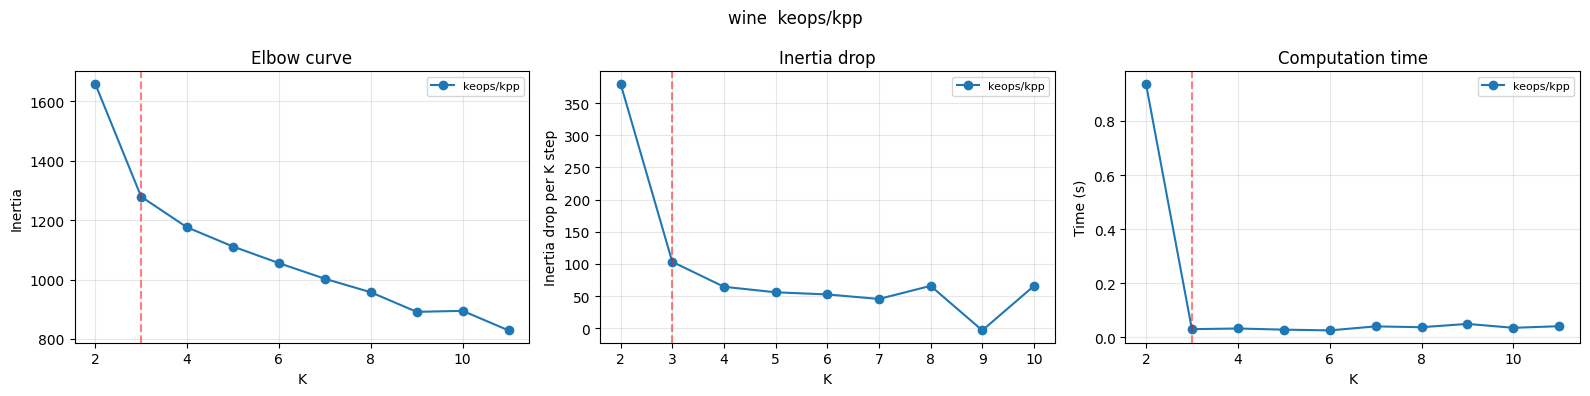

Saved kmeans_elbow_wine.png


In [33]:
# Run a kmeans tests with one init methond and a single kmeans implementation
results = run_sweep(
    [kmeans_keops],
    {'kpp': init_kmeans_plus_plus},
    x, k_values, n_init=N_INIT, n_iter=N_ITER,
    dataset_name=DATASET_NAME
)
# Show the memory usage
memory_summary(results)
# Plot the elbow chart to see where the right K might lie
plot_elbow(results)


kmeans_sklearn / kpp  K=2..11
K=  2  inertia=1,658.8  time=0.005s
K=  3  inertia=1,278.8  time=0.005s
K=  4  inertia=1,180.9  time=0.006s
K=  5  inertia=1,117.8  time=0.005s
K=  6  inertia=1,044.6  time=0.006s
K=  7  inertia=999.3  time=0.005s
K=  8  inertia=945.5  time=0.005s
K=  9  inertia=915.3  time=0.006s
K= 10  inertia=873.4  time=0.005s
K= 11  inertia=833.1  time=0.005s

kmeans_sklearn / random  K=2..11
K=  2  inertia=1,660.0  time=0.004s
K=  3  inertia=1,277.9  time=0.004s
K=  4  inertia=1,186.5  time=0.005s
K=  5  inertia=1,105.3  time=0.005s
K=  6  inertia=1,055.5  time=0.005s
K=  7  inertia=990.8  time=0.005s
K=  8  inertia=937.1  time=0.005s
K=  9  inertia=919.6  time=0.004s
K= 10  inertia=875.0  time=0.005s
K= 11  inertia=827.7  time=0.005s

kmeans_keops / kpp  K=2..11
K=  2  inertia=1,659.0  time=0.029s  peak=0.009GB
K=  3  inertia=1,277.9  time=0.036s  peak=0.009GB
K=  4  inertia=1,180.7  time=0.027s  peak=0.009GB
K=  5  inertia=1,105.0  time=0.035s  peak=0.009GB
K=  6 

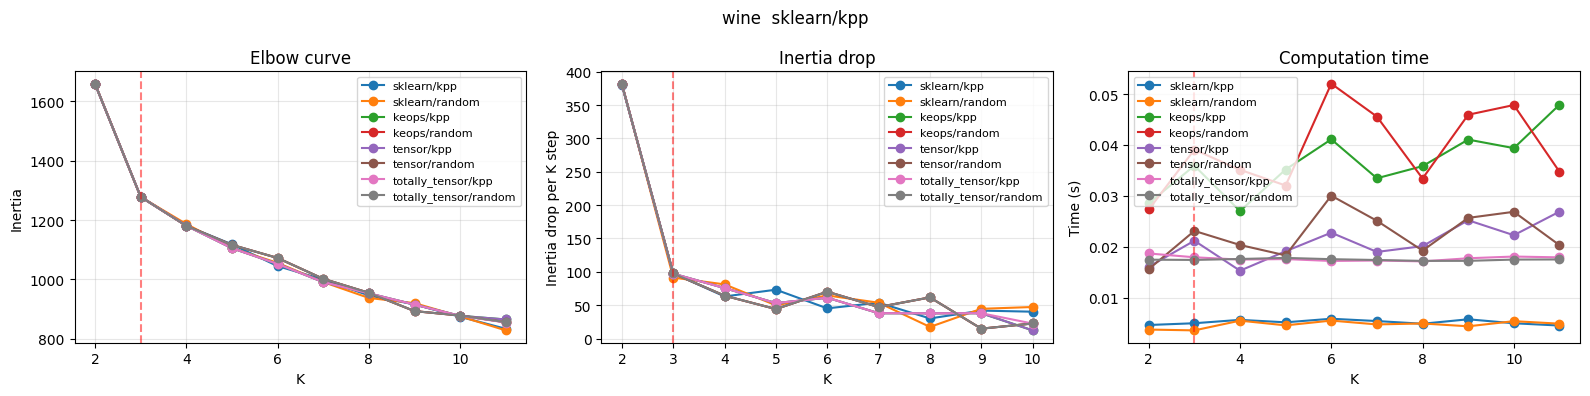

Saved kmeans_elbow_wine.png
ARI at wine  sklearn/kpp K=3
  vs ground truth:
    sklearn      / kpp         0.9149
    sklearn      / random      0.8975
    keops        / kpp         0.8975
    keops        / random      0.8975
    tensor       / kpp         0.8975
    tensor       / random      0.8975
    totally_tensor / kpp       0.8975
    totally_tensor / random    0.8975
  cross-implementation:
    sklearn/kpp          vs sklearn/random        0.9820
    sklearn/kpp          vs keops/kpp             0.9820
    sklearn/kpp          vs keops/random          0.9820
    sklearn/kpp          vs tensor/kpp            0.9820
    sklearn/kpp          vs tensor/random         0.9820
    sklearn/kpp          vs totally_tensor/kpp    0.9820
    sklearn/kpp          vs totally_tensor/random  0.9820
    sklearn/random       vs keops/kpp             1.0000
    sklearn/random       vs keops/random          1.0000
    sklearn/random       vs tensor/kpp            1.0000
    sklearn/random       

In [50]:
# Run a couple initialization methods against four kmeans implementations
results = run_sweep(
    [kmeans_sklearn, kmeans_keops, kmeans_tensor, kmeans_totally_tensor],
    {'kpp': init_kmeans_plus_plus, 'random': init_random},
    x, k_values, n_init=N_INIT, n_iter=N_ITER,
    dataset_name=DATASET_NAME
)

memory_summary(results)
plot_elbow(results)

# ARI will tell you, if there is a true score, how well the clustering was performed
compare_ari(results, k=N_CLUSTERS_TRUE, labels_true=labels_true)

In [51]:
# Verify that the silhouette implementations are working properly

sil_check = verify_silhouette_implementations(device='cuda')


Test: Well-separated  (N=2000, D=4, K=4)
  sklearn reference: 0.916866

Silhouette  [verify/ground_truth  K=4]  (full N=2000, sampled N=2000)
  PyTorch  0.916866  [0.073s]  peak=16.2 MB
[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula Sqrt(Sum((a-b)**2))*c with a=Var(0,4,0), b=Var(1,4,1), c=Var(2,4,1) ... OK
  KeOps    0.916866  [0.002s]  peak=0.2 MB
  Centroid 0.941139  [0.001s]  peak=0.1 MB
  PASS  PyTorch     score=0.916866  diff=7.74e-08  (tol=1e-04)
  PASS  KeOps       score=0.916866  diff=4.18e-08  (tol=1e-04)
  PASS  Centroid    score=0.941139  (sign check only)

Test: Overlapping  (N=2000, D=4, K=4)
  sklearn reference: 0.599449

Silhouette  [verify/ground_truth  K=4]  (full N=2000, sampled N=2000)
  PyTorch  0.599449  [0.001s]  peak=16.2 MB
  KeOps    0.599449  [0.002s]  peak=0.2 MB
  Centroid 0.705015  [0.001s]  peak=0.1 MB
  PASS  PyTorch     score=0.599449  diff=1.06e-07  (tol=1e-04)
  PASS  KeOps       score=0.599449  diff=4.66e-08  (tol=

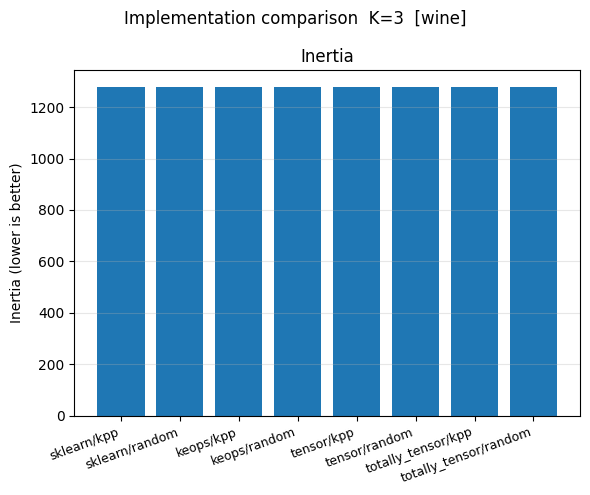

Saved kmeans_comparison_bars_K3.png


In [52]:
# Test comparison bar chart (inertia only, no silhouette yet)
# This code assumes kmeans has been run, and the results structure is populated
plot_comparison_bars(results, k=N_CLUSTERS_TRUE)

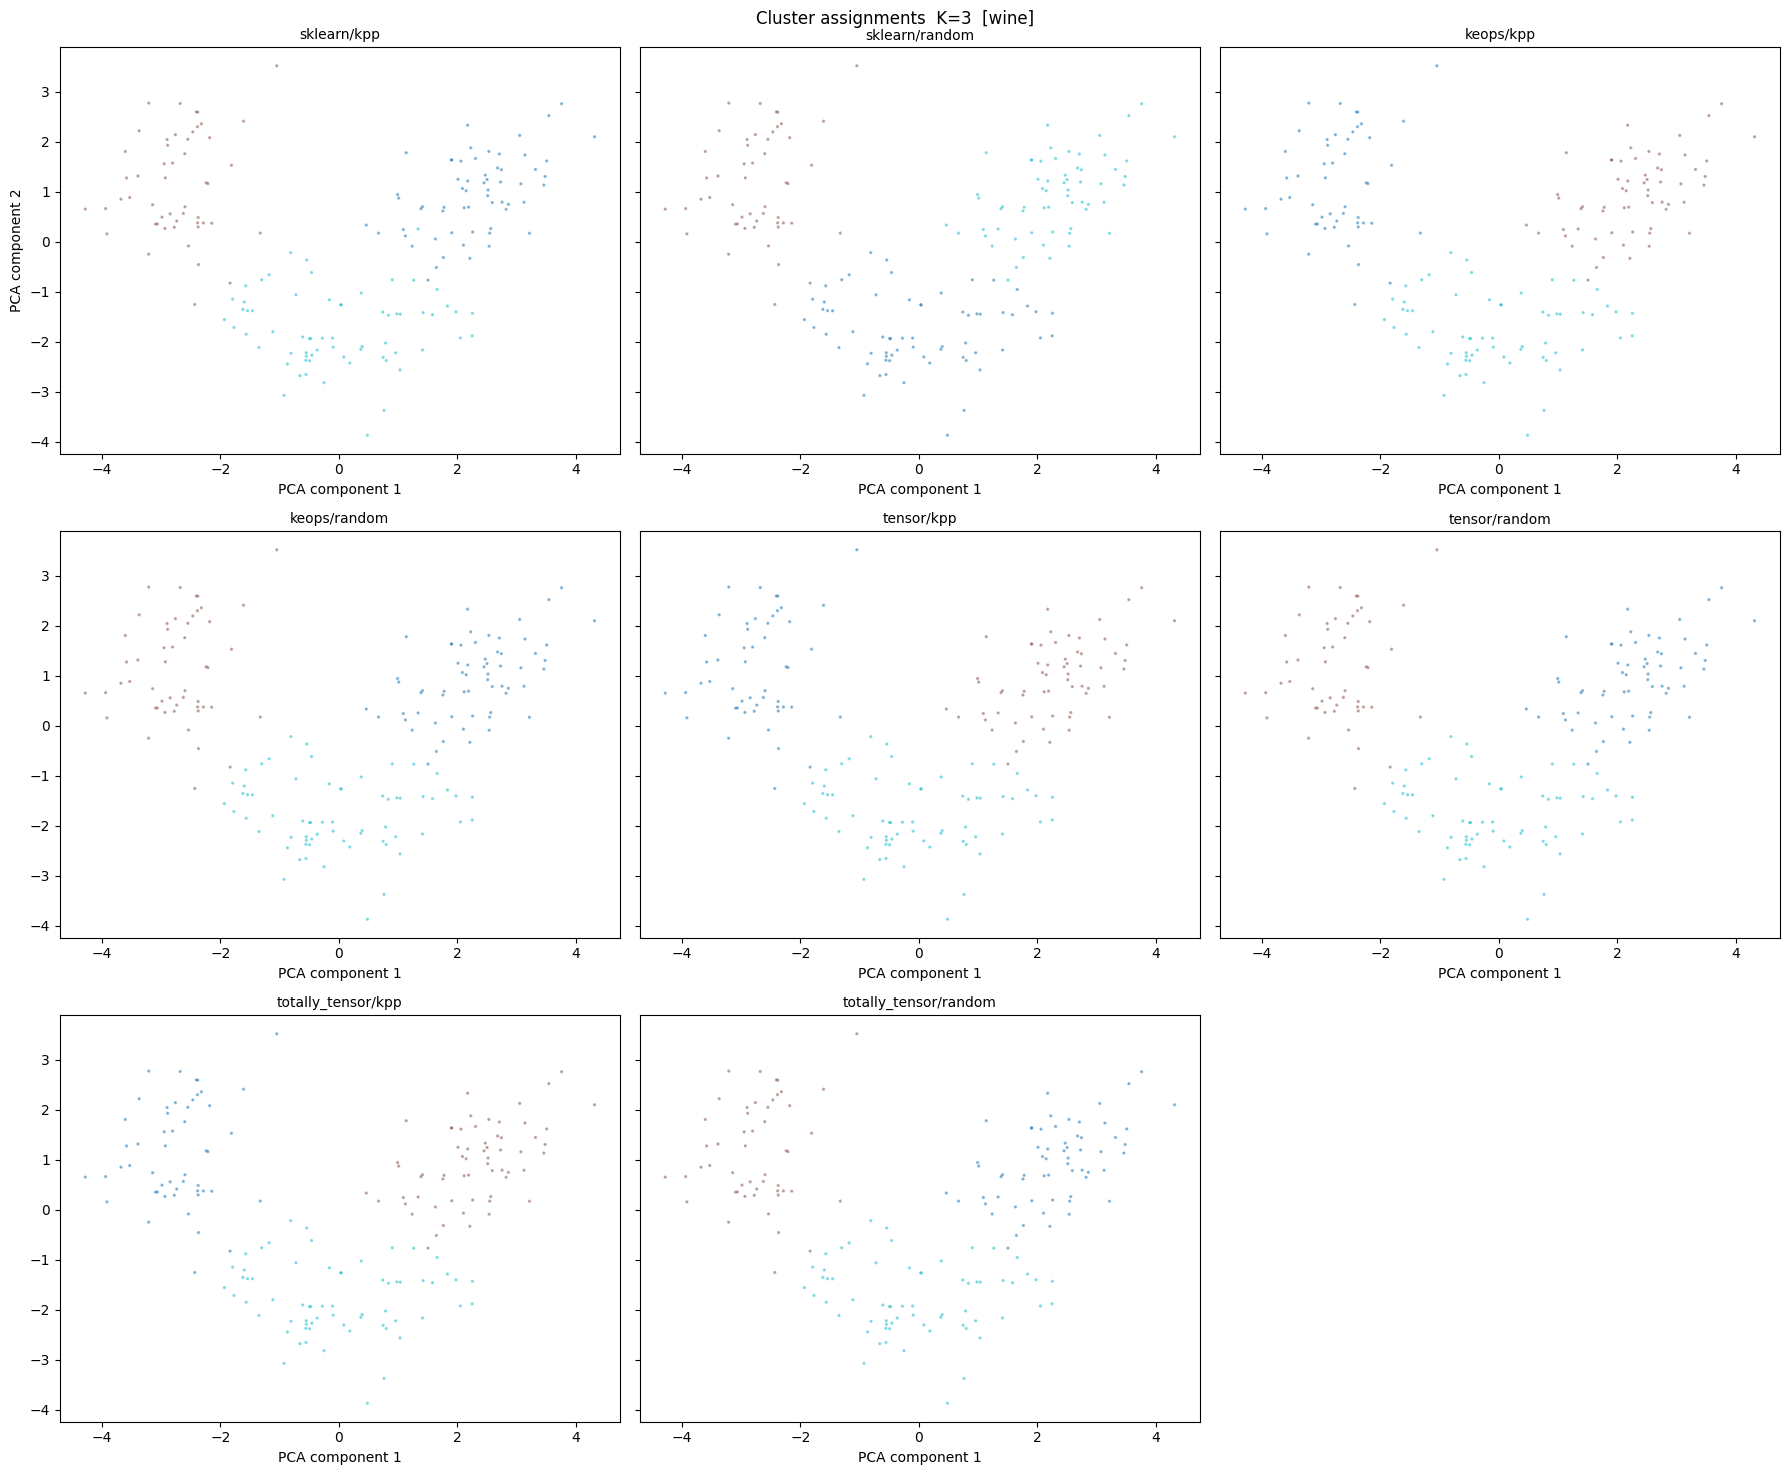

Saved kmeans_scatter_comparison_K3.png


In [53]:
# Test side-by-side scatter
# This requires kmeans to have been run, producing a results structure that is used here
plot_scatter_comparison(x, results, k=N_CLUSTERS_TRUE)

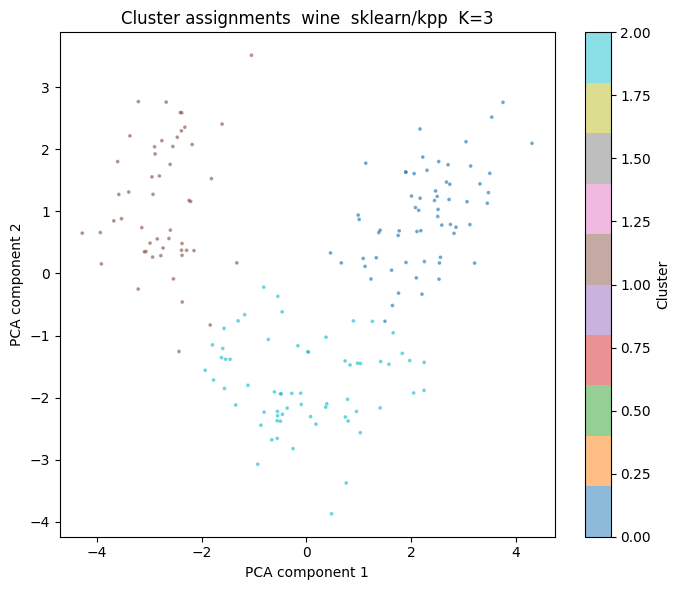

Saved kmeans_scatter_wine_K3.png


In [46]:
# See what the kmenas results actually look like
plot_scatter(x, results, k=N_CLUSTERS_TRUE)


Silhouette  [sklearn/kpp  K=3]  (full N=178, sampled N=178)
  PyTorch  0.285941  [0.002s]  peak=0.1 MB
  KeOps    0.285942  [0.001s]  peak=0.0 MB
  Centroid 0.416140  [0.001s]  peak=0.0 MB

Silhouette  [sklearn/random  K=3]  (full N=178, sampled N=178)
  PyTorch  0.284858  [0.001s]  peak=0.1 MB
  KeOps    0.284859  [0.001s]  peak=0.0 MB
  Centroid 0.416305  [0.001s]  peak=0.0 MB

Silhouette  [keops/kpp  K=3]  (full N=178, sampled N=178)
  PyTorch  0.284858  [0.001s]  peak=0.1 MB
  KeOps    0.284859  [0.001s]  peak=0.0 MB
  Centroid 0.416305  [0.000s]  peak=0.0 MB

Silhouette  [keops/random  K=3]  (full N=178, sampled N=178)
  PyTorch  0.284858  [0.001s]  peak=0.1 MB
  KeOps    0.284859  [0.001s]  peak=0.0 MB
  Centroid 0.416305  [0.001s]  peak=0.0 MB

Silhouette  [tensor/kpp  K=3]  (full N=178, sampled N=178)
  PyTorch  0.284858  [0.001s]  peak=0.1 MB
  KeOps    0.284859  [0.001s]  peak=0.0 MB
  Centroid 0.416305  [0.001s]  peak=0.0 MB

Silhouette  [tensor/random  K=3]  (full N=178, s

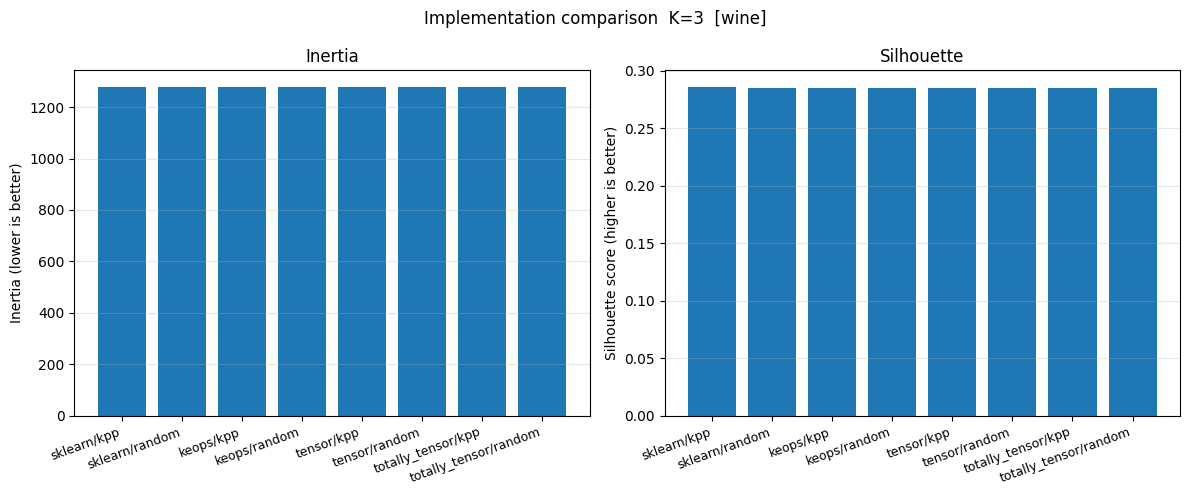

Saved kmeans_comparison_bars_K3.png


In [54]:
# Perform silhouette analysis, which is usually more accurate than elbow tests
sil = run_silhouette_on(x, filter_results(results, k=N_CLUSTERS_TRUE))
plot_comparison_bars(results, sil_results=sil, k=N_CLUSTERS_TRUE)


Silhouette  [keops/kpp  K=2]  (full N=178, sampled N=178)
  PyTorch  0.268313  [0.002s]  peak=0.1 MB
  KeOps    0.268313  [0.001s]  peak=0.0 MB
  Centroid 0.401902  [0.001s]  peak=0.0 MB

Silhouette  [keops/kpp  K=3]  (full N=178, sampled N=178)
  PyTorch  0.284858  [0.001s]  peak=0.1 MB
  KeOps    0.284859  [0.001s]  peak=0.0 MB
  Centroid 0.416305  [0.001s]  peak=0.0 MB

Silhouette  [keops/kpp  K=4]  (full N=178, sampled N=178)
  PyTorch  0.245189  [0.001s]  peak=0.1 MB
  KeOps    0.245191  [0.001s]  peak=0.0 MB
  Centroid 0.365284  [0.001s]  peak=0.0 MB

Silhouette  [keops/kpp  K=5]  (full N=178, sampled N=178)
  PyTorch  0.225926  [0.001s]  peak=0.2 MB
  KeOps    0.225929  [0.001s]  peak=0.0 MB
  Centroid 0.344247  [0.001s]  peak=0.0 MB

Silhouette  [keops/kpp  K=6]  (full N=178, sampled N=178)
  PyTorch  0.236584  [0.001s]  peak=0.2 MB
  KeOps    0.236588  [0.001s]  peak=0.0 MB
  Centroid 0.361235  [0.000s]  peak=0.0 MB

Silhouette  [keops/kpp  K=7]  (full N=178, sampled N=178)
 

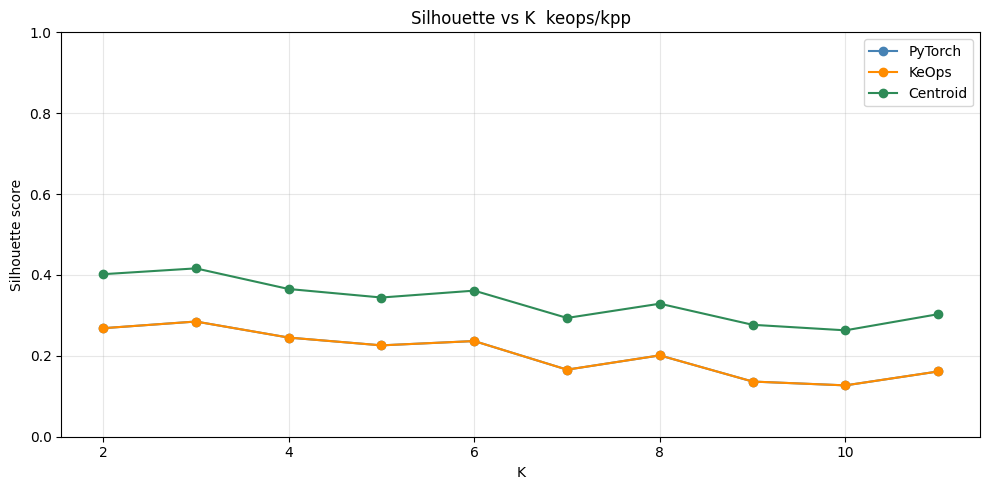

Saved silhouette_wine.png


In [55]:
# -- Silhouette score vs K (one implementation) --
sil_sweep = run_silhouette_on(
    x, filter_results(results, kmeans='keops', init='kpp')
)
plot_silhouette_benchmark(sil_sweep)

---
# KeOps vs FAISS
I discovered FAISS late in the process of experimenting with this notebook. I believe it is worth mentioning here.

[FAISS](https://github.com/facebookresearch/faiss) (Facebook AI Similarity Search) is Meta's
production-grade library for GPU-accelerated similarity search and k-means clustering.
For the data scales explored in this notebook - hundreds of thousands of points in tens of
dimensions - KeOps and FAISS perform comparably. The meaningful differences emerge at scale.
FAISS uses cuBLAS (NVIDIA's optimized matrix multiplication library) for distance computations,
which gives it an edge when dimensionality exceeds 50-100. The [KeOps benchmarks](https://www.kernel-operations.io/keops/_auto_benchmarks/benchmark_KNN.html)
confirm this directly: at high dimensions, FAISS-Flat edges out KeOps on standard Euclidean
distance, though the gap narrows on newer hardware. FAISS also handles multi-GPU workloads
transparently via a `gpu=True` flag, and can stream data from CPU memory when the dataset
exceeds GPU VRAM - demonstrated clustering [67 million vectors to 262,144 centroids](https://engineering.fb.com/2017/03/29/data-infrastructure/faiss-a-library-for-efficient-similarity-search/)
in under three hours across eight P100 GPUs.

KeOps has two meaningful advantages. First, memory efficiency: FAISS reserves 18% of GPU
memory upfront as scratch space, while KeOps's LazyTensor approach allocates almost nothing
beyond the data and centroids themselves - as seen in our runs where 500k points at 50
dimensions used under 200 MB peak on a 15.6 GB card. Second, flexibility: KeOps handles
arbitrary distance metrics (Manhattan, cosine, hyperbolic) with no code changes, while FAISS
is primarily optimized for L2 and dot product. For the standard Euclidean k-means implemented
here, either library is a reasonable choice at moderate scale. FAISS would become the stronger
option for very high dimensional data such as raw image pixels or text embeddings, or when
multi-GPU scaling is needed. A practical comparison of both libraries against scikit-learn
can be found [here](https://www.kdnuggets.com/2021/01/k-means-faster-lower-error-scikit-learn.html).

---
## KeOps Visuals

I've been experimenting with a number of different tools to generate visuals to help explain some of this work. This [K-Means video](https://www.youtube.com/watch?v=qznHmkhGcoo) uses the [manim](https://www.manim.community/) libraries developed by Grant Sanderson of [3Blue1Brown](https://www.youtube.com/c/3blue1brown) to try to explain some of what is going on here.

I also have a blog at [www.rfischer.com](www.rfischer.com) on which I will likely post on this topic in the future.

This (imperfect) tech graphic tries to explain how exactly KeOps tensorization differs from more traditional implementations:

[Standard Tensor vs KeOps](https://rfischer.com/wp-content/uploads/2026/03/KeOps-V2-scaled.png) (click to load)

This diagram contrasts how a standard GPU library (like basic PyTorch) handles a large, multi-step calculation versus how the specialized KeOps library optimizes it. The critical difference highlighted by the color coding is **where the data lives and when it travels** between slow and fast hardware memory.

Here is a breakdown of the process and the relevant engineering terms, referenced by the diagram's color scheme.

### The Hardware Layers and Their Speed Limits (Color-Coded)

The speed of a GPU operation is often not limited by the math itself (FLOPS), but by the time it takes to move data from the "storage warehouse" to the actual "computational core."

* **VRAM (Terracotta Red):** This is your main GPU Global Memory (e.g., the 24GB on an RTX 3090). It is **Large but Slow**. It has a high **Memory Bandwidth Latency**—it takes a long time to read or write data. In Diagram A, all data transfers to VRAM (the terracotta cylinders) are potential bottlenecks (highlighted in red).
* **Shared Memory (Warm Gold):** This is an ultra-fast, on-chip cache located right next to the processor cores. It is **Small but Fast**. It’s only visible to a local "Block" of threads, allowing them to cooperate by sharing data.
* **Registers & Cores (Emerald Green):** The processor cores (the small processor icons) are where the actual floating-point math happens. Registers are the absolute fastest storage, private to a single thread. They store the numbers the core is actively processing at that exact microsecond.

### Key Concepts in the Workflow

A program running on a GPU is called a **Kernel**—it’s just a piece of code compiled for GPU execution. The dominant framework for writing these kernels (and the language KeOps generates) is **CUDA** (Compute Unified Device Architecture, by NVIDIA). Because a single kernel can only do so much, GPUs use tiling to work in parallel.

* **Tiling:** Both Diagrams A and B use tiling. Large datasets ($A, B, X, Y$) are broken into small **Tiles** (e.g., $T_1(A)$ is tile 1 of Matrix A), rendered in **Purple** to represent the high-level matrix abstraction. Tiling allows a GPU "Thread Block" to cooperatively load data that fits into the **Shared Memory (Warm Gold)**.

### Comparing the Approaches

#### Diagram A: Standard Block Tiling (The Bottlenecked Assembly Line)

This approach uses multiple distinct kernels (Kernel 1: Matrix Multiplication, then Kernel 2: Exponential Calculation).

1.  **Kernel 1** loads $T_1(A)$ and $T_1(B)$ into Shared Memory (Gold), multiplies them, and **immediately writes the intermediate result $C$ (rendered in Purple, sitting inside a Red VRAM container) back to the slow VRAM (Red).**
2.  **Wait and See:** This write-back forces the GPU to stall. The diagram highlights the **Clear Stall** (the large red 'X'), where the processor (Green) is 100% idle, waiting for the slow VRAM transfer to finish.
3.  **Kernel 2** can only start after the VRAM is updated. It reads the newly calculated $T_1(C)$ (Purple) *back* from VRAM into Shared Memory (Gold), applies the exponential formula (Green), and writes the final Result (Purple) back to VRAM (Red).
4.  Standard Block Tiling is slow because you "pay the memory tax" (VRAM bandwidth latency) on every modular step. For an $N \times N$ matrix calculation, this approach consumes **$O(N^2)$ VRAM space.**

#### Diagram B: Fused Tiling via KeOps (The Optimized Continuous Chef)

KeOps optimizes this problem by realizing it’s a **Block-wise Reduction**. A "Reduction" means you iterate over many elements ($j$) to produce one final summed value for each output ($i$), which is what the `Sum_j(...)` formula defines.

1.  **Fused Tiling (The Multi-Tasker):** Instead of distinct kernels, KeOps JIT-compiles (Just-In-Time) your *entire formula* into a **Single Fused CUDA Kernel**. The kernel loads $T_1(X)$ and $T_1(Y)$ into Shared Memory (Gold) just ONCE.
2.  **Continuous Flow (Registers/SRAM Only):** Inside the loop, shown by the red 'Fusion' bracket, all calculations happen seamlessly using only the **Shared Memory (Gold)** and the **Registers/Cores (Green)**. The intermediate results (the intermediate formulas and temporary sums) **never leave the local high-speed cache.** They do not go back to Shared Memory and *definitely* never go to VRAM.
3.  **No Stalls:** Because data stays local, there are no VRAM transfer bottlenecks (no Clear Stalls/Red Xs). The GPU cores stay 100% busy doing math. Only the final, reduced answer is written to VRAM (Red) just once.
4.  Fused Tiling via KeOps is significantly faster because it eliminates nearly all slow memory traffic. Because it never saves an intermediate matrix, it uses **$O(N+M)$ VRAM space** (linear with respect to the input vectors), allowing enormous calculations to fit in standard GPU memory.

---
# Conclusions

### KeOps delivers on memory efficiency

The core claim of KeOps is that `LazyTensor` avoids materializing the `(N, K, D)` intermediate distance tensor by fusing the subtract, square, sum, and argmin into a single CUDA kernel. The benchmarks confirm this. At 500,000 points with 50 dimensions and K=12, the naive PyTorch approach requires roughly 1.2 GB per iteration just for that intermediate. The KeOps runs stayed under 200 MB peak across the entire sweep on a 15.6 GB card.

### Aggressive tensorization does not close the gap

`kmeans_totally_tensor` batches all `n_init` restarts simultaneously, which was expected to recover some of the throughput lost to Python-level restart loops. In practice it was **slower and more memory-intensive** than KeOps at scale. The fundamental problem is that batching restarts multiplies memory pressure by `n_init` -- exactly what KeOps is designed to avoid. For small datasets this doesn't matter, but it means pure PyTorch tensorization is not a substitute for kernel fusion on large problems.

### Initialization matters more as K and D grow

On small datasets (Iris, Wine), all four initialization strategies produce comparable inertia. On SUSY -- 500k points, 50 dimensions, sweeping to K=30 -- k-means++ consistently reached lower inertia than random initialization and converged faster. The mean/std and k+++ strategies were competitive on some runs but less consistent. For practical use on high-dimensional data, k-means++ is the safest default.

### KeOps vs FAISS

At the scales tested here, KeOps and FAISS are broadly comparable in runtime. FAISS becomes the stronger choice above ~50-100 dimensions (where cuBLAS matrix multiplication gives it an edge) or when multi-GPU scaling is needed. KeOps is preferable when memory is the constraint or when non-standard distance metrics are needed, since it handles arbitrary formulas with no code changes.

### What this notebook does not cover

- Streaming from CPU memory for datasets that exceed GPU VRAM
- FAISS direct comparison with timing (discussed qualitatively in the FAISS section)
